# `GEA` demo: a Disease Graph Atlas from DISEASES + STRING

**Part 1 — data extraction and graph construction.**

The GEA tutorials so far build *sample-specific* networks (LIONESS co-expression + STRING prior),
where one graph = one biological sample. That works well for the node- and edge-level SAEs, but the
graph-level SAE has little to say: "properties of one LIONESS artefact" is hard to name biologically.

This notebook builds the alternative dataset — the **Disease Graph Atlas** — in which

$$\text{one graph} \;=\; \text{one disease}$$

$$G_d = (V_d,\; E_d,\; X_d,\; W_d)$$

| symbol | content | source |
|---|---|---|
| $V_d$ | protein-coding genes associated with disease $d$ | DISEASES gene–disease associations |
| $E_d$ | interactions **among those genes** (induced subgraph, no 1-hop expansion yet) | STRING |
| $X_d$ | node features: association evidence $\Vert$ per-graph topology $\Vert$ ESM-2 protein embedding | DISEASES + STRING + ESM-2 |
| $W_d$ | edge weights: STRING confidence $s_{ij}/1000$ | STRING |

Gene identity travels with the node through its ESM-2 embedding ("*what is this protein*"), while the
graph supplies the disease context ("*what is it doing here*"). That is why variable node sets across
diseases are acceptable: nodes do not need a shared index to be comparable.

**Scope of this notebook (Part 1):** disease universe → DISEASES retrieval → QC → gene filtering →
gene→protein mapping → STRING backbone → ESM node features → PyG graphs → graph QC → export.
Deliberately *no* model: the GCN, the three SAEs and the interpretation experiments come in Part 2,
so that any weirdness later can be attributed to the model rather than the dataset.

**Deliberately simple baseline.** Induced subgraph only (no 1-hop expansion), STRING confidence as a
single edge weight, one gene set per disease. Network expansion, GRN edges and multi-evidence seed
sets are follow-up ablations, not part of the first dataset.

## 0 — Configuration

In [ ]:
import gzip
import json
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import torch
from tqdm.auto import tqdm

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_DIR   = Path("data/disgenet")         # historical name, kept so existing artefacts still resolve
STRING_DIR = DATA_DIR / "string"           # STRING bulk downloads (cached, ~160 MB)
for d in (DATA_DIR, STRING_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Tag carried by every artefact name. Seeds come from Jensen-lab DISEASES (section 2); the tag exists
# so a second seed source could be added later without overwriting this atlas.
ATLAS_TAG = "diseases"

DISEASES_DIR = DATA_DIR / "diseases"       # DISEASES bulk downloads
DISEASES_DIR.mkdir(parents=True, exist_ok=True)
DISEASES_CHANNEL  = "integrated"           # "knowledge" (curated only) | "integrated" (+GWAS+text mining)
DISEASES_MIN_CONF = 2.0                    # DISEASES confidence is a 0–5 star scale

# Artefacts carry the atlas tag in their name so two atlases never overwrite each other.
GDA_FILE     = DATA_DIR / f"gene_disease_seeds_{ATLAS_TAG}.tsv.gz"   # tidy association table (cache)
GENEMAP_FILE = DATA_DIR / f"gene_protein_map_{ATLAS_TAG}.tsv"        # gene → Ensembl → STRING protein
ENSEMBL_FILE = DATA_DIR / f"ensembl_ids_{ATLAS_TAG}.txt"             # input for get_esm_embeddings.py
ESM_FILE     = DATA_DIR / f"esm_embeddings_{ATLAS_TAG}.pt"           # output of get_esm_embeddings.py
GRAPHS_FILE  = DATA_DIR / f"disease_graphs_{ATLAS_TAG}.pt"           # the atlas itself
STATS_FILE   = DATA_DIR / f"disease_graph_stats_{ATLAS_TAG}.csv"
LABELS_FILE  = DATA_DIR / f"disease_graph_labels_{ATLAS_TAG}.json"

# ── Seed sets ────────────────────────────────────────────────────────────────
# The binding evidence cutoff is DISEASES_MIN_CONF above (2.0 of 5 → score 0.40). SEED_MIN_SCORE is a
# second gate on the normalised 0–1 score; at these defaults it never binds, and section 3 shows what
# raising the cutoff would cost.
SEED_MIN_SCORE        = 0.30
MIN_GENES_PER_DISEASE = 20     # below this a disease cannot produce a usable graph
MAX_GENES_PER_DISEASE = 500    # cap by association score: keeps |V_d| comparable across diseases
REFRESH_SEEDS         = False  # True re-reads DISEASES even when the cached seed table exists

# ── STRING ───────────────────────────────────────────────────────────────────
SPECIES          = 9606        # Homo sapiens
STRING_VERSION   = "12.0"
STRING_MIN_SCORE = 700         # high confidence; STRING's own "high" cutoff
# Edge relation split used by GEA's R-GCN (two relations). Here relation 0 = the interaction is
# supported by experiments or by a curated database ("physical/curated"), relation 1 = it is only
# supported by the inferred channels (coexpression, textmining, neighbourhood, fusion, cooccurrence).
PHYSICAL_CHANNELS = ["experimental", "database"]

# ── Graph construction ───────────────────────────────────────────────────────
# Structural node features: per-graph topology descriptors appended to every node's features.
# Without them the only per-graph variation in x is the evidence scalar — the ESM block of a protein
# is identical in every disease — and a GCN trained on such inputs collapses into a lookup table
# (measured: 97% of the variance in h_i explained by protein identity, 11% by which disease the
# protein sits in). These features make the same protein genuinely different in T2D and in
# Alzheimer's, and give the node-level SAE a topological vocabulary as well as a molecular one.
#
# Measured effect (same atlas and ESM, only these 7 columns added or removed): held-out edge AUC
# 0.867 → 0.899, identity dominance in h_i 0.944 → 0.929, node reconstruction unchanged. The
# graph-level composition confound is *not* fixed by them — corr(h_G, ESM composition) stays around
# 0.74 — because h_G is a mean over node states and is therefore a composition statistic whatever
# the inputs. That one needs a different readout (see section 15).
STRUCTURAL_FEATURES = True
STRUCTURAL_COLS = ["log_degree", "log_strength", "rel_degree", "clustering",
                   "kcore", "log_pagerank", "frac_physical"]

DROP_ISOLATED_NODES = True     # a gene with no high-confidence partner carries no graph signal
KEEP_LARGEST_CC     = False    # keep every component by default; flip to True for a stricter atlas
MIN_NODES, MIN_EDGES = 15, 20  # graphs smaller than this are dropped (reported, not silently)
ESM_PCA_DIM         = 256      # 1280 → 256 whitened PCA, as in the IBD/T2D tutorials

pd.set_option("display.width", 130)


def download_file(url, dest):
    # Cache-aware streaming download. requests (not urllib) with an explicit User-Agent, because
    # download.jensenlab.org answers 403 to urllib's default agent.
    dest = Path(dest)
    if dest.exists():
        print(f"(cached) {dest.name}  {dest.stat().st_size / 1e6:.0f} MB")
        return dest
    print(f"downloading {url}")
    with requests.get(url, stream=True, timeout=180,
                      headers={"User-Agent": "gea-disease-atlas/1.0"}) as resp:
        resp.raise_for_status()
        with open(dest, "wb") as fh:
            for block in resp.iter_content(1 << 20):
                fh.write(block)
    print(f"  → {dest.name}  {dest.stat().st_size / 1e6:.0f} MB")
    return dest


print(f"Artefacts → {DATA_DIR.resolve()}")

## 1 — The disease universe

Roughly 90 diseases spanning six biological domains. The point is **not** to build a disease
classifier: it is to obtain graphs that are biologically diverse enough for a graph-level SAE to have
something to separate. Type 2 diabetes is included deliberately — it is the bridge to the existing
mouse LIONESS experiment (`demo-t2d.ipynb`).

Diseases are addressed by **DOID**, the vocabulary DISEASES is indexed with. Each DOID below was
resolved against the DISEASES label table itself and hand-checked — automatic matching by name is not
safe here (searching "bladder carcinoma" returns *liver carcinoma* as a close string match, and
"metabolic syndrome" returns *atrial fibrillation* through an obsolete identifier). A UMLS CUI is
carried alongside as the stable internal disease id: it is what the seed table groups on and what
ends up in `data.cui`.

In [ ]:
# category, disease name (for display), UMLS CUI, DOID.
# DOID is what DISEASES is queried with; the CUI is the stable internal id. Insulin resistance,
# hypercholesterolemia and hypertriglyceridemia were dropped from earlier drafts: DOID has no
# matching concept for them (only familial variants), so they could never be looked up.
DISEASE_UNIVERSE = pd.DataFrame(
    [
        # ── metabolic ────────────────────────────────────────────────────────
        ("metabolic", "Type 2 diabetes mellitus", "C0011860", "DOID:9352"),
        ("metabolic", "Type 1 diabetes mellitus", "C0011854", "DOID:9744"),
        ("metabolic", "Obesity", "C0028754", "DOID:9970"),
        ("metabolic", "Non-alcoholic fatty liver disease", "C0400966", "DOID:0080208"),
        ("metabolic", "Metabolic syndrome X", "C0524620", "DOID:0060611"),
        ("metabolic", "Familial hypercholesterolemia", "C0020445", "DOID:13810"),
        ("metabolic", "Gout", "C0018099", "DOID:13189"),
        ("metabolic", "Phenylketonuria", "C0031485", "DOID:9281"),
        ("metabolic", "Hemochromatosis", "C0018995", "DOID:2352"),
        # ── cardiovascular ───────────────────────────────────────────────────
        ("cardiovascular", "Coronary artery disease", "C1956346", "DOID:3393"),
        ("cardiovascular", "Myocardial infarction", "C0027051", "DOID:5844"),
        ("cardiovascular", "Heart failure", "C0018801", "DOID:6000"),
        ("cardiovascular", "Hypertensive disease", "C0020538", "DOID:10763"),
        ("cardiovascular", "Atherosclerosis", "C0004153", "DOID:1936"),
        ("cardiovascular", "Dilated cardiomyopathy", "C0007193", "DOID:12930"),
        ("cardiovascular", "Hypertrophic cardiomyopathy", "C0007194", "DOID:11984"),
        ("cardiovascular", "Atrial fibrillation", "C0004238", "DOID:0060224"),
        ("cardiovascular", "Cerebrovascular accident", "C0038454", "DOID:6713"),
        ("cardiovascular", "Long QT syndrome", "C0023976", "DOID:2843"),
        ("cardiovascular", "Abdominal aortic aneurysm", "C0162871", "DOID:7693"),
        ("cardiovascular", "Pulmonary hypertension", "C0020542", "DOID:6432"),
        # ── neurological / neurodegenerative / psychiatric ───────────────────
        ("neuro", "Alzheimer's disease", "C0002395", "DOID:10652"),
        ("neuro", "Parkinson disease", "C0030567", "DOID:14330"),
        ("neuro", "Amyotrophic lateral sclerosis", "C0002736", "DOID:332"),
        ("neuro", "Huntington disease", "C0020179", "DOID:12858"),
        ("neuro", "Multiple sclerosis", "C0026769", "DOID:2377"),
        ("neuro", "Epilepsy", "C0014544", "DOID:1826"),
        ("neuro", "Schizophrenia", "C0036341", "DOID:5419"),
        ("neuro", "Bipolar disorder", "C0005586", "DOID:3312"),
        ("neuro", "Major depressive disorder", "C1269683", "DOID:1470"),
        ("neuro", "Autistic disorder", "C0004352", "DOID:12849"),
        ("neuro", "Migraine disorders", "C0149931", "DOID:6364"),
        ("neuro", "Frontotemporal dementia", "C0338451", "DOID:9255"),
        ("neuro", "Charcot-Marie-Tooth disease", "C0007959", "DOID:10595"),
        ("neuro", "Spinal muscular atrophy", "C0026847", "DOID:12377"),
        # ── immune / inflammatory ────────────────────────────────────────────
        ("immune", "Rheumatoid arthritis", "C0003873", "DOID:7148"),
        ("immune", "Crohn disease", "C0010346", "DOID:8778"),
        ("immune", "Ulcerative colitis", "C0009324", "DOID:8577"),
        ("immune", "Inflammatory bowel diseases", "C0021390", "DOID:0050589"),
        ("immune", "Systemic lupus erythematosus", "C0024141", "DOID:9074"),
        ("immune", "Psoriasis", "C0033860", "DOID:8893"),
        ("immune", "Asthma", "C0004096", "DOID:2841"),
        ("immune", "Atopic dermatitis", "C0011615", "DOID:3310"),
        ("immune", "Celiac disease", "C0007570", "DOID:10608"),
        ("immune", "Ankylosing spondylitis", "C0038013", "DOID:7147"),
        ("immune", "Sjogren's syndrome", "C1527336", "DOID:12894"),
        ("immune", "Graves disease", "C0018213", "DOID:12361"),
        ("immune", "Vitiligo", "C0042900", "DOID:12306"),
        ("immune", "Systemic scleroderma", "C0036421", "DOID:418"),
        # ── cancer ───────────────────────────────────────────────────────────
        ("cancer", "Breast carcinoma", "C0678222", "DOID:3459"),
        ("cancer", "Colorectal carcinoma", "C0009402", "DOID:9256"),
        ("cancer", "Non-small cell lung carcinoma", "C0007131", "DOID:3908"),
        ("cancer", "Small cell lung carcinoma", "C0149925", "DOID:5409"),
        ("cancer", "Prostate carcinoma", "C0600139", "DOID:10286"),
        ("cancer", "Hepatocellular carcinoma", "C2239176", "DOID:684"),
        ("cancer", "Pancreatic carcinoma", "C0235974", "DOID:4905"),
        ("cancer", "Malignant neoplasm of stomach", "C0024623", "DOID:10534"),
        ("cancer", "Ovarian carcinoma", "C0029925", "DOID:4001"),
        ("cancer", "Melanoma", "C0025202", "DOID:1909"),
        ("cancer", "Glioblastoma", "C0017636", "DOID:3068"),
        ("cancer", "Acute myeloid leukemia", "C0023467", "DOID:9119"),
        ("cancer", "Chronic lymphocytic leukemia", "C0023434", "DOID:1040"),
        ("cancer", "Renal cell carcinoma", "C0007134", "DOID:4450"),
        ("cancer", "Bladder carcinoma", "C0699885", "DOID:11054"),
        ("cancer", "Thyroid carcinoma", "C0007115", "DOID:1781"),
        ("cancer", "Multiple myeloma", "C0026764", "DOID:9538"),
        ("cancer", "Neuroblastoma", "C0027819", "DOID:769"),
        ("cancer", "Medulloblastoma", "C0025149", "DOID:0050902"),
        ("cancer", "Esophageal carcinoma", "C0152018", "DOID:1107"),
        ("cancer", "Endometrial carcinoma", "C0476089", "DOID:2871"),
        ("cancer", "Head and neck squamous cell carcinoma", "C1168401", "DOID:5520"),
        # ── other organ systems / rare monogenic ─────────────────────────────
        ("other", "Chronic obstructive pulmonary disease", "C0024117", "DOID:3083"),
        ("other", "Idiopathic pulmonary fibrosis", "C1800706", "DOID:0050156"),
        ("other", "Cystic fibrosis", "C0010674", "DOID:1485"),
        ("other", "Chronic kidney disease", "C1561643", "DOID:784"),
        ("other", "Autosomal dominant polycystic kidney disease", "C0085413", "DOID:0080322"),
        ("other", "Nephrotic syndrome", "C0027726", "DOID:1184"),
        ("other", "Liver cirrhosis", "C0023890", "DOID:5082"),
        ("other", "Osteoporosis", "C0029456", "DOID:11476"),
        ("other", "Osteoarthritis", "C0029408", "DOID:8398"),
        ("other", "Age-related macular degeneration", "C0242383", "DOID:10871"),
        ("other", "Glaucoma", "C0017601", "DOID:1686"),
        ("other", "Retinitis pigmentosa", "C0035334", "DOID:10584"),
        ("other", "Sickle cell anemia", "C0002895", "DOID:0081445"),
        ("other", "Hemophilia A", "C0019069", "DOID:12134"),
        ("other", "Duchenne muscular dystrophy", "C0013264", "DOID:11723"),
        ("other", "Marfan syndrome", "C0024796", "DOID:14323"),
        ("other", "Polycystic ovary syndrome", "C0032460", "DOID:11612"),
        ("other", "Endometriosis", "C0014175", "DOID:289"),
        ("other", "Pre-eclampsia", "C0032914", "DOID:10591"),
        ("other", "Obstructive sleep apnea", "C0520679", "DOID:0050848"),
        ("other", "Sepsis", "C0243026", "DOID:0040085"),
        ("other", "Tuberculosis", "C0041296", "DOID:399"),
    ],
    columns=["category", "disease_name", "cui", "doid"],
)

assert DISEASE_UNIVERSE["cui"].is_unique, "duplicate CUIs in the universe"
assert DISEASE_UNIVERSE["doid"].is_unique, "duplicate DOIDs in the universe"
assert (DISEASE_UNIVERSE["doid"] != "").all(), "every disease needs a DOID to be found in DISEASES"
print(f"{len(DISEASE_UNIVERSE)} diseases across {DISEASE_UNIVERSE['category'].nunique()} categories\n")
print(DISEASE_UNIVERSE["category"].value_counts().to_string())

## 2 — Disease–gene associations

Seed sets come from [DISEASES](https://diseases.jensenlab.org/) — free, no registration, and built by
the same group as STRING, so its gene identifiers are already STRING proteins. The channel file is
downloaded once (~650 MB for `integrated`) and cached under `data/disgenet/diseases/`.

**Channels.** `knowledge` is the curated channel and is thin — several diseases in the universe above
have no curated entry at all. `integrated` (curated + GWAS + text mining, the default) is far better
covered, a median of ~320 genes per disease at confidence ≥ 2, at the cost of being text-mining
heavy. `experiments` and `textmining` are accepted too if you want to isolate one line of evidence.

**Scores.** DISEASES confidence is a 0–5 star scale, divided by 5 here so the `score` column lands on
the usual 0–1 range: `DISEASES_MIN_CONF = 2.0` enters the pipeline as `score = 0.40`. There is no
evidence index or gene-specificity measure, so `ei`, `dsi`, `dpi` and `n_pmids` stay empty — they are
kept in the schema so that a second source could be slotted in later without disturbing anything
downstream, and they are zero in `node_evidence` accordingly.

> The cached seed table is keyed by the atlas tag alone, so changing `DISEASES_CHANNEL` or
> `DISEASES_MIN_CONF` has no effect until you set `REFRESH_SEEDS = True` or delete
> `gene_disease_seeds_diseases.tsv.gz`.

In [9]:
DISEASES_URL = "https://download.jensenlab.org/human_disease_{channel}_full.tsv"
DISEASES_COLUMNS = {
    "integrated":  ["gene_id", "gene_symbol", "doid", "doid_name", "conf"],
    "knowledge":   ["gene_id", "gene_symbol", "doid", "doid_name", "source", "evidence", "conf"],
    "experiments": ["gene_id", "gene_symbol", "doid", "doid_name", "source", "evidence", "conf"],
    "textmining":  ["gene_id", "gene_symbol", "doid", "doid_name", "z_score", "conf", "url"],
}
DISEASES_CONF_MAX = 5.0        # 0–5 star confidence → divided by 5 to give a 0–1 score


def fetch_diseases_file(channel=DISEASES_CHANNEL):
    return download_file(DISEASES_URL.format(channel=channel),
                         DISEASES_DIR / f"human_disease_{channel}_full.tsv")


def load_diseases_seeds(universe, channel=DISEASES_CHANNEL, min_conf=DISEASES_MIN_CONF):
    path = fetch_diseases_file(channel)
    df = pd.read_csv(path, sep="\t", header=None, names=DISEASES_COLUMNS[channel], dtype=str)
    df["conf"] = pd.to_numeric(df["conf"], errors="coerce")
    n_raw = len(df)

    # Keep protein rows only (DISEASES also lists RNA genes, which have no STRING protein / ESM entry).
    df = df[df["gene_id"].str.startswith("ENSP", na=False)]
    df = df[df["conf"] >= min_conf]
    print(f"{channel}: {n_raw:,} rows → {len(df):,} protein rows at confidence >= {min_conf}")

    merged = df.merge(universe[["doid", "cui", "disease_name", "category"]], on="doid", how="inner")

    seeds = pd.DataFrame({
        "gene_ncbi_id": np.nan,
        "gene_symbol": merged["gene_symbol"].values,
        "gene_ensembl": np.nan,
        "dsi": np.nan, "dpi": np.nan, "pli": np.nan,
        "cui": merged["cui"].values,                       # keep UMLS CUIs as the disease key
        "disease_name": merged["disease_name"].values,
        "disease_type": "disease",
        "mesh_classes": np.nan,
        "score": (merged["conf"] / DISEASES_CONF_MAX).clip(upper=1.0).values,
        "ei": np.nan, "el": np.nan, "n_pmids": np.nan, "n_snps": np.nan,
        "category": merged["category"].values,
        "disease_label": merged["disease_name"].values,
        "doid": merged["doid"].values,
    })

    covered = set(seeds["cui"])
    absent = universe[~universe["cui"].isin(covered)]
    print(f"{seeds['cui'].nunique()}/{len(universe)} diseases have seeds "
          f"({len(seeds):,} gene–disease pairs)")
    if len(absent):
        print(f"   no data at confidence >= {min_conf}: {'; '.join(absent['disease_name'])}")
    return seeds

In [ ]:
# ── Driver: cached seed table, or a fresh read of DISEASES ──────────────────
diseases = DISEASE_UNIVERSE

if GDA_FILE.exists() and not REFRESH_SEEDS:
    gdas = pd.read_csv(GDA_FILE, sep="\t", low_memory=False)
    print(f"(cache) {len(gdas):,} associations from {GDA_FILE.name}")
else:
    gdas = load_diseases_seeds(diseases)
    gdas.to_csv(GDA_FILE, sep="\t", index=False)
    print(f"Cached {len(gdas):,} associations → {GDA_FILE.name}")

gdas["score"] = pd.to_numeric(gdas["score"], errors="coerce")
print(f"\n{gdas['cui'].nunique()} diseases | {gdas['gene_symbol'].nunique():,} distinct genes")
gdas.head()

## 3 — QC of the association table

The failure mode to catch here is size heterogeneity: a disease with 12 000 genes and a disease with
4 genes cannot produce comparable graphs. We look at genes per disease, the association-score
distribution, and how the three candidate stringencies (permissive / medium / stringent) reshape the
atlas — *before* committing to a cutoff.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
CATEGORY_PALETTE = dict(zip(sorted(gdas["category"].unique()),
                            sns.color_palette("Set2", gdas["category"].nunique())))

per_disease = (
    gdas.groupby(["cui", "disease_label", "category"])
        .agg(n_genes=("gene_symbol", "nunique"),
             median_score=("score", "median"),
             max_score=("score", "max"))
        .reset_index()
        .sort_values("n_genes", ascending=False)
)

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].hist(per_disease["n_genes"], bins=40, color="#30638e")
ax[0].axvline(MIN_GENES_PER_DISEASE, color="k", ls="--", lw=1, label=f"min={MIN_GENES_PER_DISEASE}")
ax[0].axvline(MAX_GENES_PER_DISEASE, color="#d1495b", ls="--", lw=1, label=f"cap={MAX_GENES_PER_DISEASE}")
ax[0].set(title="associated genes per disease", xlabel="n genes", ylabel="n diseases")
ax[0].set_yscale("log"); ax[0].legend()

ax[1].hist(gdas["score"].dropna(), bins=40, color="#5b8c85")
floor = DISEASES_MIN_CONF / DISEASES_CONF_MAX
ax[1].axvline(floor, color="k", ls="--", lw=1, label=f"confidence {DISEASES_MIN_CONF} = {floor:.2f}")
ax[1].set(title="association score (DISEASES confidence / 5)", xlabel="score")
ax[1].set_yscale("log"); ax[1].legend()

sns.boxplot(data=per_disease, x="category", y="n_genes", ax=ax[2],
            palette=CATEGORY_PALETTE, hue="category", legend=False)
ax[2].set_yscale("log"); ax[2].set(title="genes per disease by category", xlabel="")
ax[2].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

print("Largest and smallest disease gene sets:\n")
print(pd.concat([per_disease.head(8), per_disease.tail(8)])
      [["disease_label", "category", "n_genes", "median_score"]].to_string(index=False))

In [ ]:
# How much of the atlas survives at each stringency? Only cutoffs at or above the floor already
# applied when the table was built can be explored from the cache — going below needs REFRESH_SEEDS.
rows = []
for conf in sorted({DISEASES_MIN_CONF, 2.5, 3.0, 3.5}):
    cutoff = conf / DISEASES_CONF_MAX
    sub = gdas[gdas["score"] >= cutoff]
    counts = sub.groupby("cui")["gene_symbol"].nunique()
    usable = counts[counts >= MIN_GENES_PER_DISEASE]
    rows.append(dict(confidence=conf, score=round(cutoff, 2), associations=len(sub),
                     diseases=counts.size, usable_diseases=usable.size,
                     median_genes=int(counts.median()) if counts.size else 0,
                     max_genes=int(counts.max()) if counts.size else 0))
print(pd.DataFrame(rows).to_string(index=False))
print(f"\nfloor applied when the table was built: confidence >= {DISEASES_MIN_CONF} "
      f"(score {DISEASES_MIN_CONF / DISEASES_CONF_MAX:.2f})")

## 4 — Gene filtering and identifier mapping

Three things happen here, in order:

1. **Protein-coding only** — required by construction: a node must have a protein sequence for its
   ESM-2 embedding and a STRING entry for its edges. `mygene` maps NCBI gene IDs → Ensembl gene ID +
   symbol + biotype in one query.
2. **Evidence cutoff** — `score >= SEED_MIN_SCORE`, on top of the DISEASES confidence floor
   already applied when the seed table was built.
3. **Size cap** — the top `MAX_GENES_PER_DISEASE` genes by association score, so that graph size does
   not become the dominant axis of variation for the graph-level SAE.

Every step reports what it removed.

In [13]:
import mygene

gene_keys = (
    gdas[["gene_ncbi_id", "gene_symbol", "gene_ensembl"]]
    .drop_duplicates(subset=["gene_symbol"])
    .reset_index(drop=True)
)
has_ncbi = gene_keys["gene_ncbi_id"].notna().mean()
print(f"{len(gene_keys):,} distinct genes | NCBI ID present for {has_ncbi:.0%}")

# Query by NCBI gene ID when available (unambiguous), otherwise by symbol.
mg = mygene.MyGeneInfo()
use_ncbi = has_ncbi > 0.5
query_ids = (gene_keys["gene_ncbi_id"] if use_ncbi else gene_keys["gene_symbol"]).dropna().astype(str)
info = mg.querymany(
    query_ids.tolist(),
    scopes="entrezgene" if use_ncbi else "symbol",
    fields="symbol,ensembl.gene,type_of_gene",
    species="human", as_dataframe=True, verbose=False,
)
info = info[~info.index.duplicated(keep="first")]


def _first_ensembl(row):
    # mygene returns either 'ensembl.gene' (1:1) or 'ensembl' (a list of dicts, 1:many)
    val = row.get("ensembl.gene")
    if isinstance(val, str):
        return val
    ens = row.get("ensembl")
    if isinstance(ens, list) and ens:
        return ens[0].get("gene")
    if isinstance(ens, dict):
        return ens.get("gene")
    return None


info["ensembl_id"] = info.apply(_first_ensembl, axis=1)
info["biotype"] = info.get("type_of_gene", pd.Series(index=info.index, dtype=object))

gene_map = gene_keys.copy()
gene_map["_key"] = (gene_map["gene_ncbi_id"] if use_ncbi else gene_map["gene_symbol"]).astype(str)
gene_map = gene_map.join(info[["symbol", "ensembl_id", "biotype"]], on="_key")
gene_map["symbol"] = gene_map["symbol"].fillna(gene_map["gene_symbol"])

n_before = len(gene_map)
gene_map = gene_map[gene_map["biotype"].astype(str).str.contains("protein", case=False, na=False)]
gene_map = gene_map[gene_map["ensembl_id"].notna()].drop_duplicates(subset=["gene_symbol"])
print(f"Protein-coding with an Ensembl gene ID: {n_before:,} → {len(gene_map):,} genes")

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


6,858 distinct genes | NCBI ID present for 0%
Protein-coding with an Ensembl gene ID: 6,858 → 6,764 genes


In [ ]:
# Apply the evidence cutoff + size cap, then drop diseases that end up too small.
flt = gdas[gdas["score"] >= SEED_MIN_SCORE].copy()
print(f"score >= {SEED_MIN_SCORE}: {len(gdas):,} → {len(flt):,} associations")

flt = flt.merge(gene_map[["gene_symbol", "symbol", "ensembl_id"]], on="gene_symbol", how="inner")
print(f"protein-coding + mappable:   → {len(flt):,} associations")

flt = (flt.sort_values("score", ascending=False)
          .drop_duplicates(subset=["cui", "ensembl_id"])
          .groupby("cui", group_keys=False)
          .head(MAX_GENES_PER_DISEASE))
print(f"top-{MAX_GENES_PER_DISEASE} per disease:    → {len(flt):,} associations")

sizes = flt.groupby("cui")["ensembl_id"].nunique()
too_small = sizes[sizes < MIN_GENES_PER_DISEASE]
flt = flt[~flt["cui"].isin(too_small.index)]
if len(too_small):
    dropped = (per_disease.set_index("cui").loc[too_small.index, "disease_label"]
               + " (" + too_small.astype(str) + ")")
    print(f"\nDropped {len(too_small)} diseases with < {MIN_GENES_PER_DISEASE} usable genes:")
    print("   " + "; ".join(dropped.tolist()))

print(f"\nSeed sets ready: {flt['cui'].nunique()} diseases, "
      f"{flt['ensembl_id'].nunique():,} distinct genes, {len(flt):,} associations")
print(flt.groupby("cui")["ensembl_id"].nunique().describe().round(1).to_string())

## 5 — The STRING backbone

One global interaction network, downloaded once (~160 MB, cached in `data/disgenet/string/`), from
which every disease graph is cut. We use the **detailed** links file rather than the REST API for two
reasons: it is reproducible (a fixed release), and it keeps the individual evidence channels
(`experimental`, `database`, `coexpression`, `textmining`, …) that the edge-level SAE may want later.

Edges are kept at `combined_score >= 700` (STRING's "high confidence"). The weight stored on the edge
is $w_{ij} = s_{ij}/1000 \in (0, 1]$ — never a binary adjacency, so the edge SAE can distinguish
"these proteins interact" from "these proteins interact with strong experimental support".

In [15]:
STRING_FILES = {
    "links":   f"protein.links.detailed.v{STRING_VERSION}/{SPECIES}.protein.links.detailed.v{STRING_VERSION}.txt.gz",
    "info":    f"protein.info.v{STRING_VERSION}/{SPECIES}.protein.info.v{STRING_VERSION}.txt.gz",
    "aliases": f"protein.aliases.v{STRING_VERSION}/{SPECIES}.protein.aliases.v{STRING_VERSION}.txt.gz",
}
STRING_BASE_URL = "https://stringdb-downloads.org/download"


def fetch_string_file(kind):
    remote = STRING_FILES[kind]
    return download_file(f"{STRING_BASE_URL}/{remote}", STRING_DIR / Path(remote).name)


links_path   = fetch_string_file("links")
info_path    = fetch_string_file("info")
aliases_path = fetch_string_file("aliases")

(cached) 9606.protein.links.detailed.v12.0.txt.gz  140 MB
(cached) 9606.protein.info.v12.0.txt.gz  2 MB
(cached) 9606.protein.aliases.v12.0.txt.gz  20 MB


In [16]:
# ── Identifier bridges: Ensembl gene ID / symbol → STRING protein ID ─────────
aliases = pd.read_csv(aliases_path, sep="\t", names=["string_id", "alias", "source"],
                      skiprows=1, dtype=str)
info = pd.read_csv(info_path, sep="\t", dtype=str).rename(
    columns={"#string_protein_id": "string_id"})

# Primary bridge: STRING's own Ensembl_gene alias (ENSG → ENSP), one row per protein.
ensg = (aliases[aliases["source"] == "Ensembl_gene"]
        .drop_duplicates(subset="alias")
        .set_index("alias")["string_id"])
# Secondary bridge: preferred name (HGNC symbol) for genes whose ENSG is not listed.
sym = info.drop_duplicates(subset="preferred_name").set_index("preferred_name")["string_id"]

print(f"STRING v{STRING_VERSION}: {info['string_id'].nunique():,} human proteins | "
      f"{len(ensg):,} Ensembl-gene aliases | {len(sym):,} preferred names")

gene_map["string_id"] = gene_map["ensembl_id"].map(ensg)
fallback = gene_map["string_id"].isna()
gene_map.loc[fallback, "string_id"] = gene_map.loc[fallback, "symbol"].map(sym)

mapped = gene_map["string_id"].notna()
print(f"\nGene → STRING protein: {mapped.sum():,}/{len(gene_map):,} ({mapped.mean():.1%}) "
      f"[{(~fallback & mapped).sum():,} via Ensembl, {(fallback & mapped).sum():,} via symbol]")
gene_map = gene_map[mapped].copy()

# A STRING protein may be reachable from more than one gene ID; keep one gene per protein.
gene_map = gene_map.drop_duplicates(subset="string_id")
gene_map.to_csv(GENEMAP_FILE, sep="\t", index=False)
gene_map[["gene_symbol", "symbol", "ensembl_id", "string_id"]].head()

STRING v12.0: 19,699 human proteins | 19,699 Ensembl-gene aliases | 19,699 preferred names

Gene → STRING protein: 6,764/6,764 (100.0%) [6,474 via Ensembl, 290 via symbol]


,gene_symbol,symbol,ensembl_id,string_id
0,FKBP4,FKBP4,ENSG00000004478,9606.ENSP00000001008
1,FUCA2,FUCA2,ENSG00000001036,9606.ENSP00000002165
2,CFTR,CFTR,ENSG00000001626,9606.ENSP00000003084
3,USP28,USP28,ENSG00000048028,9606.ENSP00000003302
4,HSPB6,HSPB6,ENSG00000004776,9606.ENSP00000004982


In [17]:
# Per-disease mapping QC — which diseases lose the most genes on the way to STRING?
seeds = flt.merge(gene_map[["ensembl_id", "string_id", "symbol"]], on="ensembl_id", how="left")
mapping_qc = (
    seeds.groupby(["cui", "disease_label", "category"])
         .agg(n_genes=("ensembl_id", "nunique"),
              n_mapped=("string_id", lambda s: s.notna().sum()))
         .reset_index()
)
mapping_qc["frac_mapped"] = mapping_qc["n_mapped"] / mapping_qc["n_genes"]
print(f"Median mapping rate across diseases: {mapping_qc['frac_mapped'].median():.1%}")
print("\nWorst-mapped diseases:")
print(mapping_qc.nsmallest(5, "frac_mapped")[
    ["disease_label", "n_genes", "n_mapped", "frac_mapped"]].to_string(index=False))

# Drop unmapped genes and collapse duplicate (disease, protein) rows, keeping the best evidence.
seeds = (seeds[seeds["string_id"].notna()]
         .sort_values("score", ascending=False)
         .drop_duplicates(subset=["cui", "string_id"])
         .reset_index(drop=True))
print(f"\nSeed table: {len(seeds):,} (disease, protein) pairs | "
      f"{seeds['string_id'].nunique():,} distinct proteins")

Median mapping rate across diseases: 100.0%

Worst-mapped diseases:
                disease_label  n_genes  n_mapped  frac_mapped
          Alzheimer's disease      500       500          1.0
Amyotrophic lateral sclerosis      415       415          1.0
           Sickle cell anemia       91        91          1.0
         Rheumatoid arthritis      500       500          1.0
                       Asthma      500       500          1.0

Seed table: 28,831 (disease, protein) pairs | 5,784 distinct proteins


In [18]:
# ── Load the interaction network, restricted to the atlas' protein universe ──
protein_universe = set(seeds["string_id"].unique())
USE_COLS = ["protein1", "protein2", "experimental", "database", "combined_score"]

kept = []
reader = pd.read_csv(links_path, sep=" ", usecols=USE_COLS, chunksize=2_000_000)
for chunk in tqdm(reader, desc="Scanning STRING links"):
    chunk = chunk[chunk["combined_score"] >= STRING_MIN_SCORE]
    chunk = chunk[chunk["protein1"].isin(protein_universe) & chunk["protein2"].isin(protein_universe)]
    kept.append(chunk[chunk["protein1"] < chunk["protein2"]])   # each pair is listed twice; keep one

links = pd.concat(kept, ignore_index=True)
del kept
links["weight"] = links["combined_score"] / 1000.0
links["physical"] = (links[PHYSICAL_CHANNELS] > 0).any(axis=1)

print(f"\n{len(links):,} unique interactions at combined_score >= {STRING_MIN_SCORE} "
      f"among {len(protein_universe):,} proteins")
print(f"  experimental/database supported: {links['physical'].mean():.1%}")
print(f"  weight: median {links['weight'].median():.3f}, mean {links['weight'].mean():.3f}")

Scanning STRING links: 0it [00:00, ?it/s]


69,565 unique interactions at combined_score >= 700 among 5,784 proteins
  experimental/database supported: 71.3%
  weight: median 0.843, mean 0.850


## 6 — ESM-2 node features

Protein identity is supplied by ESM-2, exactly as in the IBD and T2D tutorials: the embeddings are
computed **once** for the whole protein universe and every disease graph then slices the rows it
needs. This is what makes variable node sets defensible — two graphs sharing no genes are still
comparable, because their nodes live in the same protein representation space.

Run once (GPU recommended), from the repository root:

```bash
python docs/scripts/get_esm_embeddings.py \
    --gene-list docs/tutorial/data/disgenet/ensembl_ids_diseases.txt \
    --out       docs/tutorial/data/disgenet/esm_embeddings_diseases.pt \
    --species   human \
    --model     facebook/esm2_t33_650M_UR50D
```

If the file is absent the notebook still builds the atlas, using the association-evidence vector alone as
node features, and says so — Part 2 (GCN with an ESM-reconstruction objective) requires the real
embeddings.

In [19]:
from gea.utils import compress_embeddings_pca, load_esm_embeddings

# Global protein table — this row order defines node indices everywhere downstream.
proteins = (gene_map[gene_map["string_id"].isin(protein_universe)]
            [["string_id", "ensembl_id", "symbol"]]
            .drop_duplicates(subset="string_id")
            .sort_values("string_id")
            .reset_index(drop=True))
p_index = pd.Series(proteins.index.values, index=proteins["string_id"])
print(f"Protein universe: {len(proteins):,} proteins")

ENSEMBL_FILE.write_text("\n".join(proteins["ensembl_id"].tolist()))
print(f"Gene list for the ESM script → {ENSEMBL_FILE}")

esm_matrix, esm_available, esm_present = None, False, set()
if ESM_FILE.exists():
    try:    # metadata-only read: we only need the key set for the coverage QC
        esm_present = set(torch.load(ESM_FILE, weights_only=False, map_location="meta"))
    except Exception:                                   # noqa: BLE001
        esm_present = set(torch.load(ESM_FILE, weights_only=False))
    esm_matrix = load_esm_embeddings(str(ESM_FILE), proteins["ensembl_id"].tolist(), aggregation="mean")
    esm_matrix = compress_embeddings_pca(esm_matrix, n_components=ESM_PCA_DIM, whiten=True)
    esm_available = True
    print(f"ESM-2 node features: {tuple(esm_matrix.shape)}")
else:
    print(f"!! {ESM_FILE} not found — building graphs with association-evidence features only.\n"
          f"   Run the command above, then re-run this cell and section 7.")

Protein universe: 5,784 proteins
Gene list for the ESM script → data/disgenet/ensembl_ids_diseases.txt


Loading ESM-2 embeddings: 100%|██████████| 5784/5784 [00:00<00:00, 33976.86it/s]


Found ESM-2 embeddings for 5361/5784 genes.
PCA: 1280→256 dims, 87.8% variance retained.
ESM-2 node features: (5784, 256)


## 7 — Graph construction

For each disease $d$:

$$V_d = \{\text{mapped protein-coding DISEASES genes}\},\qquad
  E_d = \{(u,v) \in E_{\text{STRING}} : u,v \in V_d\}$$

i.e. the **induced subgraph** — no 1-hop expansion in this baseline. Isolated nodes (no
high-confidence partner inside the disease gene set) are dropped by default, since they contribute no
message passing, and the fraction dropped is recorded per disease.

Node features carry three blocks. The **structural** block is what makes a node's features depend on
the disease it sits in — degree, weighted strength, degree relative to graph size, local clustering,
k-core, PageRank and the fraction of its edges that are experimentally supported. They are computed
on the final graph and then standardised across the whole atlas, so "hub" means the same thing in a
200-node graph and a 1000-node one.

Each `Data` object follows the layout the GEA models already expect:

| field | content |
|---|---|
| `x` | `[disease-association score ‖ structural features ‖ ESM-2 PCA]` — the first block plays the role `expression` plays in the LIONESS graphs, the last is protein identity |
| `n_struct` | width of the structural block, so Part 2 knows where the identity block starts |
| `node_evidence` | association evidence per node: `score, ei, dsi, dpi, log1p(n_pmids)` — DISEASES populates only `score`; the other four are zero placeholders kept for schema stability |
| `edge_index`, `edge_attr` | both directions; weight $= s_{ij}/1000$ |
| `edge_type` | `0` = experimental/database supported, `1` = inferred channels only (the two R-GCN relations) |
| `y`, `y_dis` | disease **category** and disease identity, integer-encoded |
| `gene_symbols`, `ensembl_ids`, `string_ids` | node identity, for enrichment and plotting |

In [20]:
import networkx as nx
from torch_geometric.data import Data

# Edge arrays in global protein-index space — membership tests then become O(1) per edge.
E1 = links["protein1"].map(p_index).to_numpy()
E2 = links["protein2"].map(p_index).to_numpy()
EW = links["weight"].to_numpy(dtype=np.float32)
EP = links["physical"].to_numpy()

EVIDENCE_COLS = ["score", "ei", "dsi", "dpi", "log1p_pmids"]
seeds["log1p_pmids"] = np.log1p(pd.to_numeric(seeds.get("n_pmids"), errors="coerce").fillna(0))
for col in ["ei", "dsi", "dpi"]:
    seeds[col] = pd.to_numeric(seeds[col], errors="coerce").fillna(0.0)

categories = sorted(seeds["category"].unique())
cat_map = {c: i for i, c in enumerate(categories)}
disease_names = sorted(seeds["disease_label"].unique())
dis_map = {d: i for i, d in enumerate(disease_names)}


def structural_features(ia, ib, w, phys, n_nodes):
    # Per-graph topology descriptors, computed on the disease subgraph itself. Everything here is
    # cheap on graphs of a few hundred nodes; betweenness is deliberately left out (O(nm)).
    g = nx.Graph()
    g.add_nodes_from(range(n_nodes))
    g.add_weighted_edges_from(zip(ia.tolist(), ib.tolist(), w.tolist()))

    deg = np.array([g.degree(i) for i in range(n_nodes)], dtype=np.float32)
    strength = np.array([g.degree(i, weight="weight") for i in range(n_nodes)], dtype=np.float32)
    clustering = np.array([v for _, v in sorted(nx.clustering(g, weight="weight").items())],
                          dtype=np.float32)
    core = np.array([v for _, v in sorted(nx.core_number(g).items())], dtype=np.float32)
    pagerank = np.array([v for _, v in sorted(nx.pagerank(g, weight="weight").items())],
                        dtype=np.float32)

    # Fraction of a node's edges that are experimentally or database supported rather than inferred.
    phys_sum = np.zeros(n_nodes, dtype=np.float32)
    np.add.at(phys_sum, ia, phys.astype(np.float32))
    np.add.at(phys_sum, ib, phys.astype(np.float32))
    frac_phys = phys_sum / np.maximum(deg, 1)

    return np.stack([
        np.log1p(deg),
        np.log1p(strength),
        deg / max(n_nodes - 1, 1),
        clustering,
        core,
        np.log1p(pagerank * n_nodes),
        frac_phys,
    ], axis=1).astype(np.float32)


def build_disease_graph(sub):
    # sub: the seed rows of one disease, one row per (disease, protein)
    nodes = np.sort(sub["p_idx"].to_numpy())
    member = np.zeros(len(proteins), dtype=bool)
    member[nodes] = True

    sel = member[E1] & member[E2]
    a, b, w, phys = E1[sel], E2[sel], EW[sel], EP[sel]

    if DROP_ISOLATED_NODES:
        connected = np.unique(np.concatenate([a, b])) if len(a) else np.array([], dtype=int)
        nodes = connected
    if KEEP_LARGEST_CC and len(nodes):
        import scipy.sparse as sp
        from scipy.sparse.csgraph import connected_components
        loc = -np.ones(len(proteins), dtype=np.int64); loc[nodes] = np.arange(len(nodes))
        adj = sp.coo_matrix((np.ones(len(a)), (loc[a], loc[b])), shape=(len(nodes),) * 2)
        n_cc, lab = connected_components(adj, directed=False)
        keep = lab == np.bincount(lab).argmax()
        nodes = nodes[keep]
        member = np.zeros(len(proteins), dtype=bool); member[nodes] = True
        sel2 = member[a] & member[b]
        a, b, w, phys = a[sel2], b[sel2], w[sel2], phys[sel2]

    if len(nodes) < MIN_NODES or len(a) < MIN_EDGES:
        return None, dict(n_nodes=len(nodes), n_edges=len(a), dropped=True)

    local = -np.ones(len(proteins), dtype=np.int64)
    local[nodes] = np.arange(len(nodes))
    ia, ib = local[a], local[b]

    # Node-aligned evidence, in the same order as `nodes`
    ev = (sub.set_index("p_idx").loc[nodes, EVIDENCE_COLS]
             .astype(np.float32).to_numpy())
    evidence = torch.from_numpy(ev)

    struct = (torch.from_numpy(structural_features(ia, ib, w, phys, len(nodes)))
              if STRUCTURAL_FEATURES else torch.zeros(len(nodes), 0))

    blocks = [evidence[:, :1], struct]
    if esm_available:
        blocks.append(esm_matrix[nodes])
    elif not STRUCTURAL_FEATURES:
        blocks = [evidence]                       # nothing else to offer the model
    else:
        blocks.append(evidence[:, 1:])
    x = torch.cat(blocks, dim=1)

    edge_index = torch.tensor(np.stack([np.concatenate([ia, ib]),
                                        np.concatenate([ib, ia])]), dtype=torch.long)
    edge_attr = torch.tensor(np.concatenate([w, w]), dtype=torch.float32)
    edge_type = torch.tensor(np.concatenate([~phys, ~phys]).astype(np.int64), dtype=torch.long)

    row = sub.iloc[0]
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    data.edge_type = edge_type
    data.node_evidence = evidence
    data.y = torch.tensor(cat_map[row["category"]], dtype=torch.long)
    data.y_dis = torch.tensor(dis_map[row["disease_label"]], dtype=torch.long)
    data.disease = row["disease_label"]
    data.category = row["category"]
    data.cui = row["cui"]
    data.sample_name = row["disease_label"]          # GEA annotation helpers key on this
    data.gene_symbols = proteins.loc[nodes, "symbol"].tolist()
    data.ensembl_ids = proteins.loc[nodes, "ensembl_id"].tolist()
    data.string_ids = proteins.loc[nodes, "string_id"].tolist()
    data.n_seed_genes = int(len(sub))
    data.n_struct = int(struct.shape[1])

    stats = dict(n_nodes=len(nodes), n_edges=len(a), dropped=False)
    return data, stats

In [21]:
seeds["p_idx"] = seeds["string_id"].map(p_index).astype(int)

graphs, build_log = [], []
for (cui, label, category), sub in tqdm(seeds.groupby(["cui", "disease_label", "category"]),
                                        desc="Building disease graphs"):
    data, stats = build_disease_graph(sub)
    isolated = 1 - stats["n_nodes"] / sub["p_idx"].nunique()
    build_log.append(dict(cui=cui, disease=label, category=category,
                          n_seed_genes=sub["p_idx"].nunique(), frac_isolated=isolated, **stats))
    if data is not None:
        graphs.append(data)

build_log = pd.DataFrame(build_log)
dropped = build_log[build_log["dropped"]]
print(f"\nBuilt {len(graphs)} disease graphs "
      f"({len(dropped)} dropped for < {MIN_NODES} nodes / < {MIN_EDGES} edges)")
if len(dropped):
    print(dropped[["disease", "n_seed_genes", "n_nodes", "n_edges"]].to_string(index=False))
# Standardise the structural block across the whole atlas, so that "hub" is comparable between a
# 200-node graph and a 1000-node one. Done after the loop because it needs every graph's values.
N_STRUCT = int(graphs[0].n_struct) if graphs else 0
if N_STRUCT:
    block = torch.cat([g.x[:, 1:1 + N_STRUCT] for g in graphs])
    mu, sd = block.mean(0), block.std(0).clamp(min=1e-6)
    for g in graphs:
        g.x[:, 1:1 + N_STRUCT] = (g.x[:, 1:1 + N_STRUCT] - mu) / sd
    print("\nStructural features (raw, before standardisation):")
    print(pd.DataFrame(block.numpy(), columns=STRUCTURAL_COLS)
          .describe().loc[["mean", "50%", "min", "max"]].round(3).to_string())

IDENTITY_START = 1 + N_STRUCT          # x[:, IDENTITY_START:] is the protein-identity block
print(f"\nNode feature dim: {graphs[0].x.shape[1]} = 1 evidence + {N_STRUCT} structural + "
      f"{graphs[0].x.shape[1] - IDENTITY_START} identity "
      f"({'ESM-2 PCA' if esm_available else 'association evidence — no ESM'})")

Building disease graphs:   0%|          | 0/91 [00:00<?, ?it/s]


Built 90 disease graphs (1 dropped for < 15 nodes / < 20 edges)
        disease  n_seed_genes  n_nodes  n_edges
Phenylketonuria            23       13       22

Structural features (raw, before standardisation):
      log_degree  log_strength  rel_degree  clustering   kcore  log_pagerank  frac_physical
mean       2.905         2.753       0.080       0.429  15.597         0.644          0.567
50%        2.996         2.857       0.053       0.416  14.000         0.598          0.591
min        0.693         0.531       0.002       0.000   1.000         0.155          0.000
max        5.529         5.358       1.000       1.000  34.000         2.081          1.000

Node feature dim: 264 = 1 evidence + 7 structural + 256 identity (ESM-2 PCA)


## 8 — Graph QC

The question this section answers is *are these graphs comparable at all?* Anything that is dominated
by one huge hairball, or that shatters into singletons, will confuse the graph-level SAE far more than
any modelling choice made later.

In [22]:
import networkx as nx


def to_networkx(data):
    g = nx.Graph()
    g.add_nodes_from(range(data.num_nodes))
    ei = data.edge_index.numpy()
    w = data.edge_attr.numpy()
    half = ei.shape[1] // 2                              # both directions are stored; use one
    g.add_weighted_edges_from(zip(ei[0, :half], ei[1, :half], w[:half]))
    return g


rows = []
for data in tqdm(graphs, desc="Graph statistics"):
    g = to_networkx(data)
    deg = np.array([d for _, d in g.degree()])
    comps = list(nx.connected_components(g))
    lcc = max(comps, key=len)
    communities = nx.community.louvain_communities(g, weight="weight", seed=0)
    esm_cov = (np.mean([e in esm_present for e in data.ensembl_ids]) if esm_present else np.nan)
    rows.append(dict(
        disease=data.disease, category=data.category, cui=data.cui,
        n_seed_genes=data.n_seed_genes, n_nodes=g.number_of_nodes(), n_edges=g.number_of_edges(),
        density=nx.density(g), deg_mean=deg.mean(), deg_median=np.median(deg), deg_max=deg.max(),
        n_components=len(comps), lcc_frac=len(lcc) / g.number_of_nodes(),
        clustering=nx.average_clustering(g, weight="weight"),
        assortativity=nx.degree_assortativity_coefficient(g),
        modularity=nx.community.modularity(g, communities, weight="weight"),
        frac_physical=float((data.edge_type == 0).float().mean()),
        mean_weight=float(data.edge_attr.mean()), esm_coverage=esm_cov,
    ))

stats = pd.DataFrame(rows).sort_values("n_nodes", ascending=False).reset_index(drop=True)
stats.to_csv(STATS_FILE, index=False)
print(stats.describe().loc[["mean", "50%", "min", "max"],
      ["n_nodes", "n_edges", "density", "deg_mean", "n_components", "lcc_frac",
       "clustering", "modularity"]].round(3).to_string())

Graph statistics:   0%|          | 0/90 [00:00<?, ?it/s]

      n_nodes    n_edges  density  deg_mean  n_components  lcc_frac  clustering  modularity
mean  300.367   4177.544    0.108    23.832         2.289     0.985       0.454       0.388
50%   316.500   3344.500    0.080    24.229         2.000     0.995       0.435       0.393
min    20.000     66.000    0.028     5.500         1.000     0.827       0.372       0.090
max   499.000  10213.000    0.650    40.934        10.000     1.000       0.738       0.675


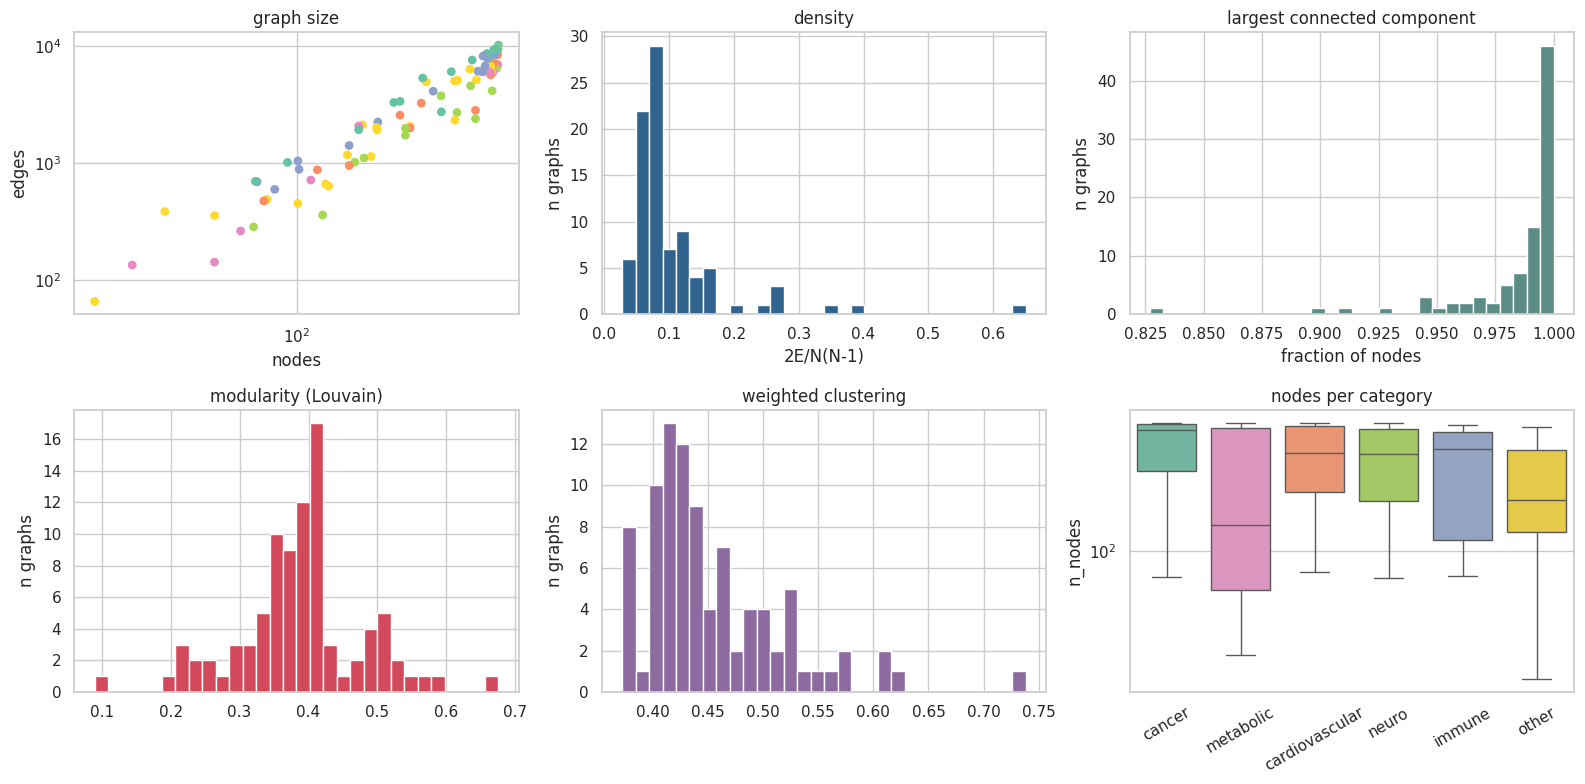

Flagged 3 graphs (small, fragmented, or near-complete):
                      disease  category  n_nodes  n_edges  density  lcc_frac
                       Sepsis     other       35      387 0.650420       1.0
Familial hypercholesterolemia metabolic       27      135 0.384615       1.0
              Marfan syndrome     other       20       66 0.347368       1.0

Largest / smallest graphs:
                      disease       category  n_nodes  n_edges  density  modularity
         Colorectal carcinoma         cancer      499    10213 0.082197    0.410524
     Hepatocellular carcinoma         cancer      498     9442 0.076297    0.398638
     Type 2 diabetes mellitus      metabolic      497     6934 0.056257    0.421485
              Atherosclerosis cardiovascular      496     8445 0.068793    0.413009
         Renal cell carcinoma         cancer      496     9687 0.078910    0.428837
         Metabolic syndrome X      metabolic       52      143 0.107843    0.429948
      Obstructive sl

In [23]:
fig, ax = plt.subplots(2, 3, figsize=(16, 8))
ax = ax.ravel()
ax[0].scatter(stats["n_nodes"], stats["n_edges"], s=28,
              c=[CATEGORY_PALETTE[c] for c in stats["category"]])
ax[0].set(xscale="log", yscale="log", xlabel="nodes", ylabel="edges", title="graph size")
ax[1].hist(stats["density"], bins=30, color="#30638e"); ax[1].set(title="density", xlabel="2E/N(N-1)")
ax[2].hist(stats["lcc_frac"], bins=30, color="#5b8c85")
ax[2].set(title="largest connected component", xlabel="fraction of nodes")
ax[3].hist(stats["modularity"], bins=30, color="#d1495b"); ax[3].set(title="modularity (Louvain)")
ax[4].hist(stats["clustering"], bins=30, color="#8d6a9f"); ax[4].set(title="weighted clustering")
sns.boxplot(data=stats, x="category", y="n_nodes", ax=ax[5], palette=CATEGORY_PALETTE,
            hue="category", legend=False)
ax[5].set(yscale="log", title="nodes per category", xlabel="")
ax[5].tick_params(axis="x", rotation=30)
for a in ax:
    a.set_ylabel(a.get_ylabel() or "n graphs")
plt.tight_layout(); plt.show()

flags = stats[(stats["n_nodes"] < 40) | (stats["lcc_frac"] < 0.5) | (stats["density"] > 0.4)]
print(f"Flagged {len(flags)} graphs (small, fragmented, or near-complete):")
print(flags[["disease", "category", "n_nodes", "n_edges", "density", "lcc_frac"]].to_string(index=False)
      if len(flags) else "   none")
print("\nLargest / smallest graphs:")
print(pd.concat([stats.head(5), stats.tail(5)])
      [["disease", "category", "n_nodes", "n_edges", "density", "modularity"]].to_string(index=False))

## 9 — A look at individual disease networks

Sanity check, not analysis: do the graphs look like disease modules — a connected core of well-known
genes plus periphery — or like noise? Only the largest connected component is drawn; node size is
degree, colour is the association score, and the ten highest-degree genes are labelled.

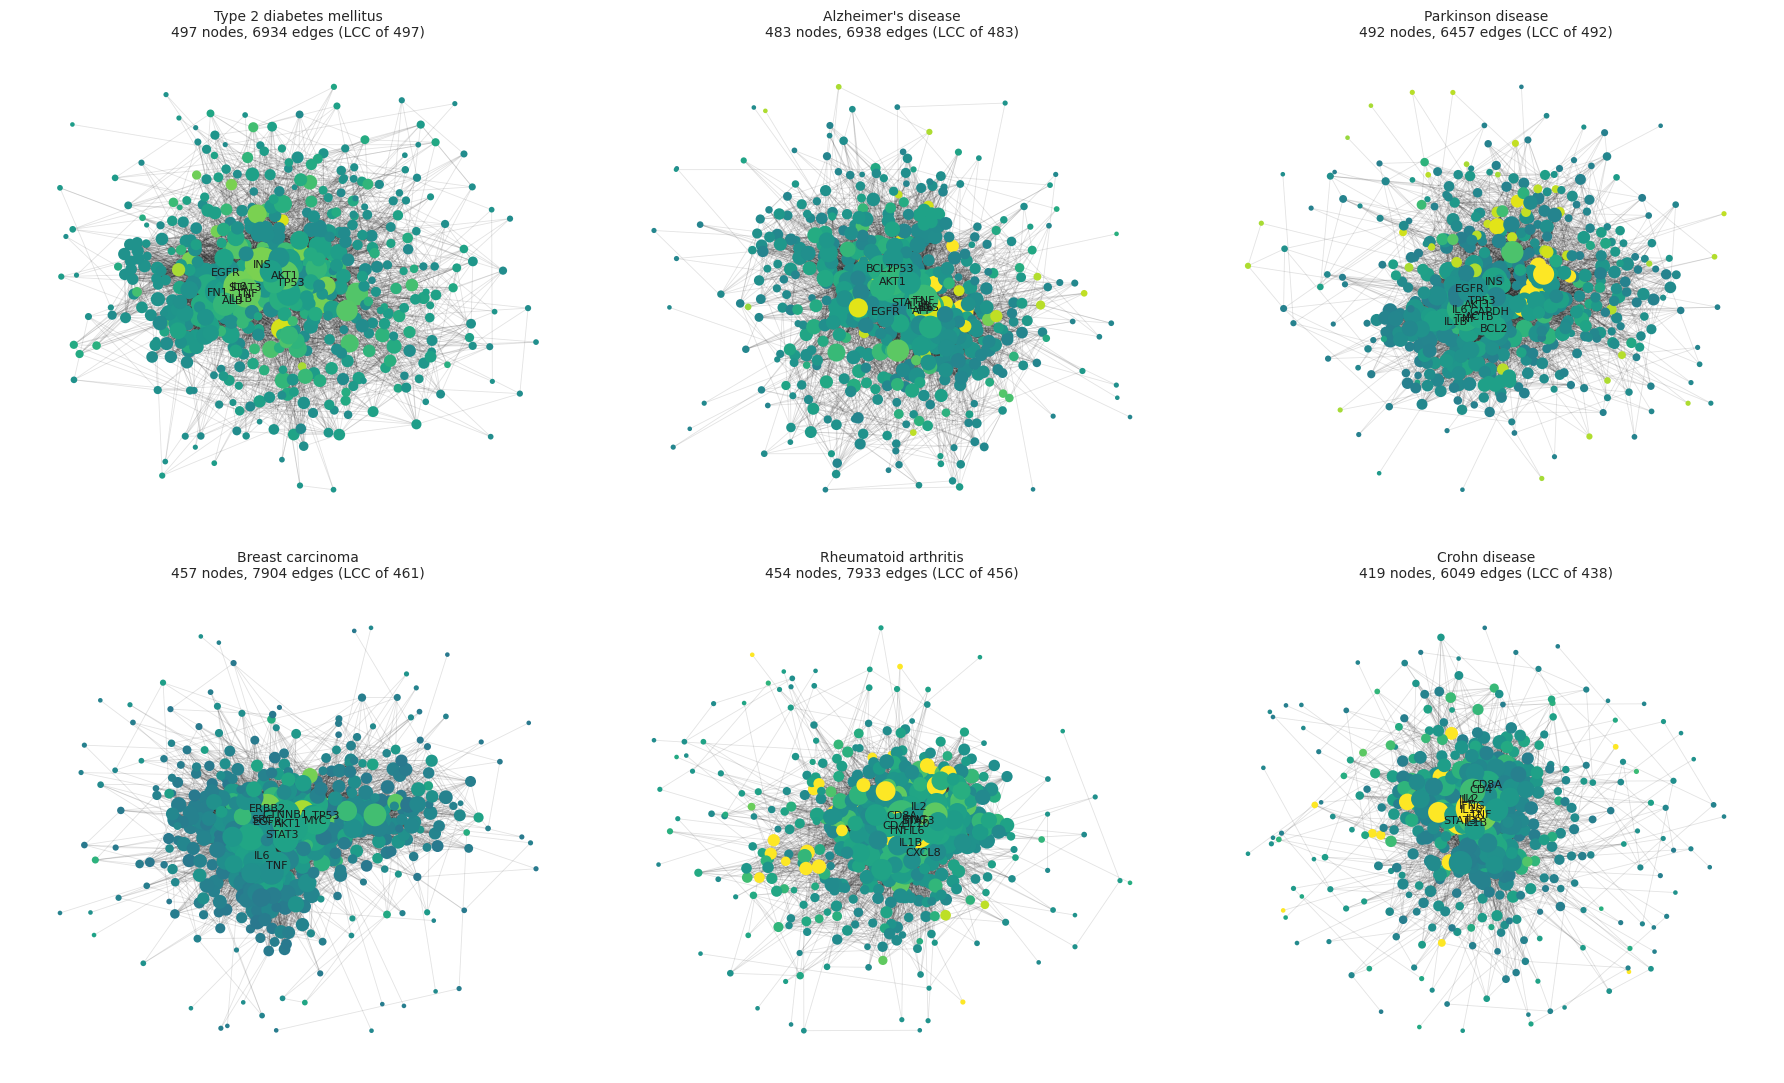

In [24]:
SHOWCASE = ["Type 2 diabetes mellitus", "Alzheimer's disease", "Parkinson disease",
            "Breast carcinoma", "Rheumatoid arthritis", "Crohn disease"]
by_name = {g.disease: g for g in graphs}
showcase = [by_name[d] for d in SHOWCASE if d in by_name][:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for axis, data in zip(axes.ravel(), showcase):
    g = to_networkx(data)
    lcc = g.subgraph(max(nx.connected_components(g), key=len))
    pos = nx.spring_layout(lcc, weight="weight", seed=42, k=0.35)
    deg = dict(lcc.degree())
    score = data.node_evidence[:, 0].numpy()
    nx.draw_networkx_edges(lcc, pos, ax=axis, alpha=0.12, width=0.6)
    nx.draw_networkx_nodes(lcc, pos, ax=axis, node_size=[8 + 3 * deg[n] for n in lcc],
                           node_color=[score[n] for n in lcc], cmap="viridis", vmin=0, vmax=1,
                           linewidths=0)
    hubs = sorted(lcc, key=lambda n: deg[n], reverse=True)[:10]
    nx.draw_networkx_labels(lcc, pos, ax=axis, font_size=8,
                            labels={n: data.gene_symbols[n] for n in hubs})
    axis.set_title(f"{data.disease}\n{lcc.number_of_nodes()} nodes, {lcc.number_of_edges()} edges "
                   f"(LCC of {g.number_of_nodes()})", fontsize=10)
    axis.axis("off")
for axis in axes.ravel()[len(showcase):]:
    axis.axis("off")
plt.tight_layout(); plt.show()

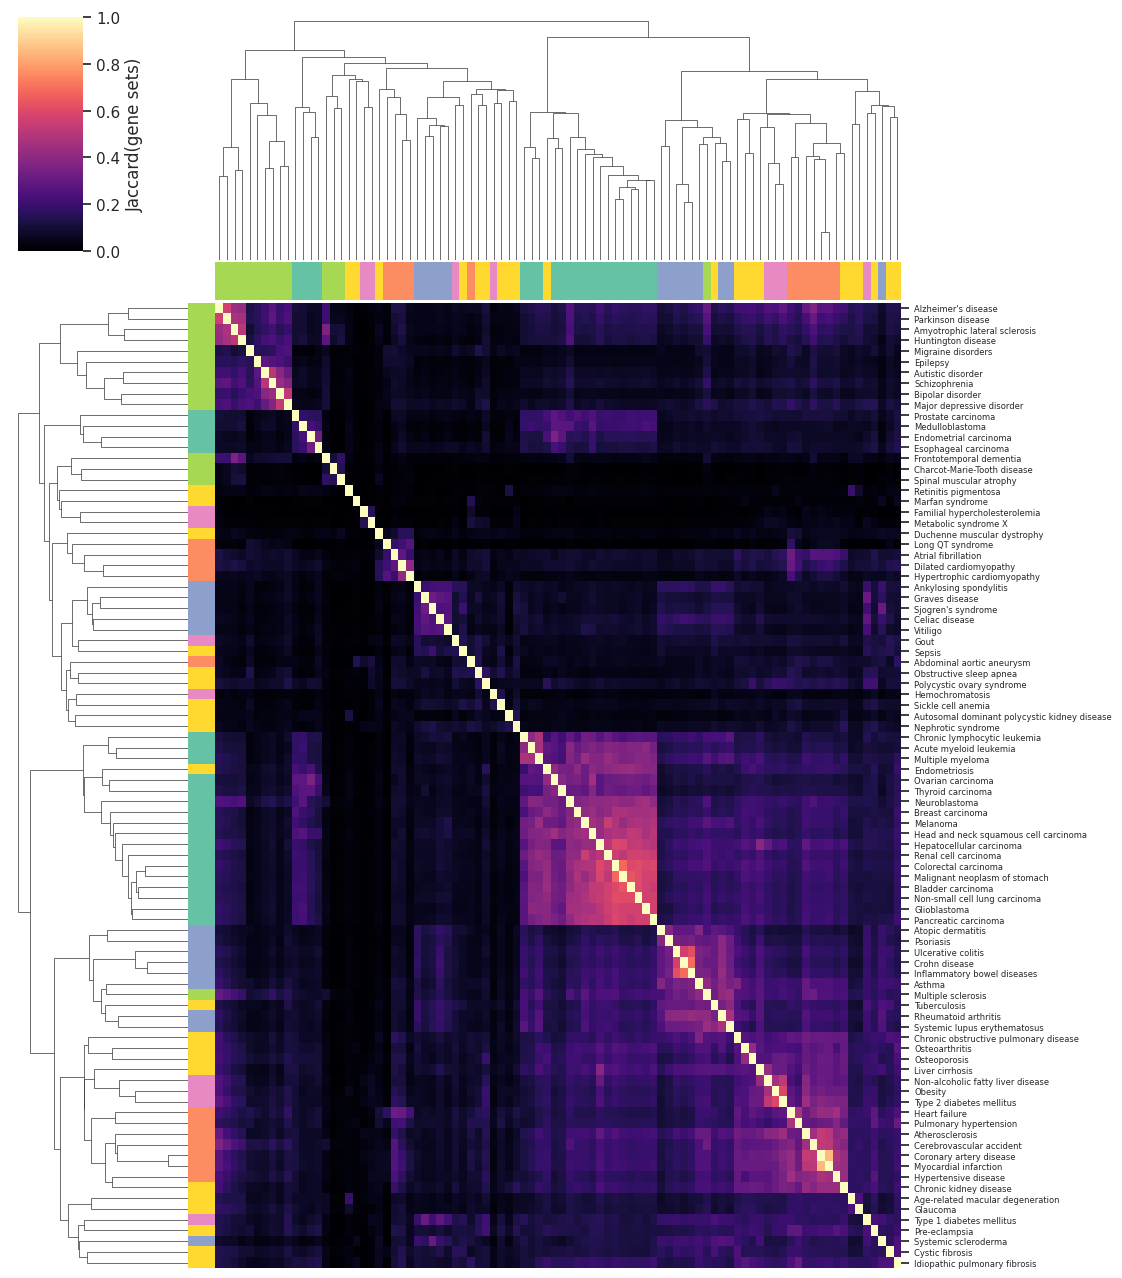

Pairwise gene-set overlap: median 0.089, 90th pct 0.241, max 0.853


In [25]:
# Gene-overlap baseline (Jaccard) — the first of the disease-similarity baselines the plan calls for,
# and the one to keep in mind when a graph-level SAE feature later groups a set of diseases together.
names = [g.disease for g in graphs]
sets = [set(g.string_ids) for g in graphs]
J = np.zeros((len(sets), len(sets)), dtype=np.float32)
for i, si in enumerate(sets):
    for j, sj in enumerate(sets):
        J[i, j] = len(si & sj) / len(si | sj)

order = np.argsort([f"{g.category}|{g.disease}" for g in graphs])
cat_colors = [CATEGORY_PALETTE[graphs[i].category] for i in order]
cg = sns.clustermap(pd.DataFrame(J[np.ix_(order, order)],
                                 index=[names[i] for i in order], columns=[names[i] for i in order]),
                    row_colors=cat_colors, col_colors=cat_colors, cmap="magma",
                    row_cluster=True, col_cluster=True, figsize=(13, 13),
                    xticklabels=False, yticklabels=1, cbar_kws=dict(label="Jaccard(gene sets)"))
cg.ax_heatmap.set_yticklabels(cg.ax_heatmap.get_yticklabels(), fontsize=6)
plt.show()

iu = np.triu_indices(len(sets), k=1)
print(f"Pairwise gene-set overlap: median {np.median(J[iu]):.3f}, "
      f"90th pct {np.quantile(J[iu], 0.9):.3f}, max {J[iu].max():.3f}")

## 10 — Export

The atlas is saved in the same format as `t2d_graphs.pt` / `ibd_graphs.pt`, so Part 2 can load it with
`torch.load(...)` and hand it straight to a loader.

In [ ]:
torch.save(graphs, GRAPHS_FILE)
LABELS_FILE.write_text(json.dumps(
    dict(category_to_idx=cat_map, disease_to_idx=dis_map,
         n_struct=N_STRUCT, structural_cols=STRUCTURAL_COLS if N_STRUCT else [],
         identity_start=IDENTITY_START,
         esm_available=bool(esm_available), esm_pca_dim=ESM_PCA_DIM if esm_available else None,
         seed_source="DISEASES", diseases_channel=DISEASES_CHANNEL,
         diseases_min_conf=DISEASES_MIN_CONF, seed_min_score=SEED_MIN_SCORE,
         string_version=STRING_VERSION, string_min_score=STRING_MIN_SCORE,
         max_genes_per_disease=MAX_GENES_PER_DISEASE, drop_isolated=DROP_ISOLATED_NODES,
         keep_largest_cc=KEEP_LARGEST_CC), indent=2))

print(f"{len(graphs)} graphs → {GRAPHS_FILE}")
print(f"per-graph statistics → {STATS_FILE}")
print(f"label maps + build parameters → {LABELS_FILE}\n")
print(f"nodes  : {stats['n_nodes'].min()}–{stats['n_nodes'].max()} (median {stats['n_nodes'].median():.0f})")
print(f"edges  : {stats['n_edges'].min()}–{stats['n_edges'].max()} (median {stats['n_edges'].median():.0f})")
print(f"feature dim: {graphs[0].x.shape[1]}")
print("\ngraphs per category:")
print(stats["category"].value_counts().to_string())

### Where Part 1 ends

The atlas is now the frozen part of the experiment: from here on, anything surprising is the model's
doing, not the dataset's. **Part 2 continues below** (section 11) with the self-supervised GCN, and
Part 3 will add the three SAEs on top of its node, edge and graph representations.

Ablations named in the plan and already parameterised by section 0: 1-hop network expansion,
shuffled ESM features, degree-preserving edge rewiring, disease holdout, and transfer to the mouse
T2D LIONESS graphs.

---

# Part 2 — a self-supervised GCN over the disease atlas

The atlas is frozen; this half turns each disease graph into representations the three GEA SAEs can
later decompose. Following the design settled in the planning discussion, the encoder is deliberately
plain — a **weighted GCN**, not a Graph Transformer, not GINE, no learned pooling — because anything
the encoder compresses aggressively is something the SAE can no longer recover.

$$x_i = [\,\text{evidence}_i \,\Vert\, \text{structure}_i \,\Vert\, \text{ESM}_i\,]
\;\xrightarrow{\;\text{GCN}(A_{ij}=s_{ij}^{\text{STRING}})\;}\; h_i$$

and the three levels all come from those same contextualised node states:

| level | representation | objective |
|---|---|---|
| node | $h_i$ | reconstruct the protein's own ESM-2 vector — keeps molecular identity in $h_i$ |
| edge | $h_{ij} = \tfrac{1}{2}(h_i + h_j)$ | regress the STRING confidence $s_{ij}$ of **held-out** edges |
| graph | $h_G = \frac{1}{\lvert V_G\rvert}\sum_i h_i$ | contrastive: two lightly perturbed views of the same disease graph attract, different diseases repel |

$$\mathcal{L} = \lambda_N \mathcal{L}_N + \lambda_E \mathcal{L}_E + \lambda_G \mathcal{L}_G$$

**No disease-label supervision.** Training the encoder to classify disease would bake the label into
the representation, and the graph-level SAE would then rediscover the labels rather than biology.
Disease categories are used *only* as a held-out evaluation probe in section 15.

**Three departures from the literal plan, each because the naive version is trivially solvable:**

1. **Edges are masked.** Every training step hides a fraction of each graph's edges from message
   passing and predicts their confidence from the remaining network. Reconstructing edges the encoder
   can see is a lookup, not a task. This is the objective that works best on this atlas — held-out
   edges separate from non-edges at AUC 0.909 (section 15).
2. **The encoder is residual** and the node term is a cosine rather than a squared error — see the
   comments in section 13. Both exist for the same reason: without them the node objective is not
   just hard but unsatisfiable, and it contributes no gradient worth speaking of.
3. **Negative pairs are included.** After the `combined_score ≥ 700` filter, observed confidences live
   in a narrow band (~0.7–1.0), so a constant predictor already scores well. Sampling non-adjacent
   pairs within the same graph as zero-confidence targets turns the objective into "*is* there an
   interaction, and how strong" and makes the metric in section 15 meaningful. Set
   `EDGE_NEG_RATIO = 0` to fall back to the literal formulation.

## 11 — Resume point, configuration and split

Everything below runs from `disease_graphs_*.pt`, so Part 2 can be re-run without rebuilding the
atlas.

> **On the size of the atlas.** With ~60–90 graphs the *node* and *edge* objectives are not
> data-starved at all — they see $10^4$–$10^5$ nodes and $10^5$–$10^6$ edges — but the *contrastive*
> objective is, since it has at most a few dozen negatives per batch. Expect the graph level to be the
> noisiest, and treat section 15's probe as indicative rather than conclusive. If you want more
> graphs, in rough order of effort: lower `DISEASES_MIN_CONF` (with `REFRESH_SEEDS = True`), lower
> `MIN_GENES_PER_DISEASE`, extend `DISEASE_UNIVERSE` — DISEASES covers ~2,900 DOIDs with 20+ genes at
> confidence 2 — or take the plan's disease × tissue route, which multiplies the atlas rather than
> adding to it.

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from tqdm.auto import tqdm

from gea.gea import set_seed

# ── Resume: reload the atlas if it is not already in memory ──────────────────
try:
    graphs
except NameError:
    graphs = torch.load(GRAPHS_FILE, weights_only=False)
    print(f"(resumed) loaded {len(graphs)} graphs from {GRAPHS_FILE}")

# ── Encoder ─────────────────────────────────────────────────────────────────
INPUT_PROJ_DIM = 256          # identity block → 256; evidence + structure stay unprojected
GCN_HIDDEN     = [256, 256]   # message-passing widths; 2 layers = 2-hop receptive field
GCN_LATENT     = 128          # dim of h_i, h_ij and h_G — what the SAEs will see
GCN_DROPOUT    = 0.2
CONTRAST_DIM   = 64           # SimCLR-style projection head, discarded after training

# ── Objectives ──────────────────────────────────────────────────────────────
LAMBDA_NODE, LAMBDA_EDGE, LAMBDA_GRAPH = 1.0, 1.0, 0.5
EDGE_MASK_FRAC = 0.15         # fraction of undirected edges hidden from message passing each step
EDGE_NEG_RATIO = 1.0          # non-adjacent pairs sampled per masked edge (0 = literal formulation)
TEMPERATURE    = 0.2          # NT-Xent temperature

# ── Augmentations for the contrastive views (conservative on purpose) ───────
AUG_EDGE_DROP     = 0.15
AUG_NODE_DROP     = 0.00      # off by default — measured to make things worse, see section 12
AUG_WEIGHT_JITTER = 0.05      # std of Gaussian noise on STRING confidences
AUG_FEATURE_MASK  = 0.10      # fraction of node-feature dimensions zeroed

# ── Optimisation ────────────────────────────────────────────────────────────
EPOCHS, LR, WEIGHT_DECAY, BATCH_SIZE = 300, 1e-3, 1e-4, 8
PATIENCE  = 40                # early stopping on validation loss
VAL_FRAC  = 0.2
SEED      = 42
GCN_CKPT  = DATA_DIR / f"disease_gcn_{ATLAS_TAG}.pt"

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
try:                                   # defined in section 3 when Part 1 ran in this kernel
    CATEGORY_PALETTE
except NameError:
    _cats = sorted({g.category for g in graphs})
    CATEGORY_PALETTE = dict(zip(_cats, sns.color_palette("Set2", len(_cats))))

# Feature layout, read off the graphs: x = [evidence (1) | structural (N_STRUCT) | identity (rest)]
IN_CHANNELS = graphs[0].x.shape[1]
N_STRUCT = int(getattr(graphs[0], "n_struct", 0) or 0)
IDENTITY_START = 1 + N_STRUCT
RECON_DIM = IN_CHANNELS - IDENTITY_START         # only the identity block is the node target
if RECON_DIM < 1:
    raise ValueError("node features carry no identity block to reconstruct")
print(f"{len(graphs)} graphs | node features {IN_CHANNELS} "
      f"(1 evidence + {N_STRUCT} structural + {RECON_DIM} identity) | device: {device}")
if N_STRUCT == 0:
    print("!! No structural features on these graphs. The identity block is the same for a protein "
          "in every\n   disease, so the encoder has no per-graph signal to work with beyond node "
          "presence — rebuild\n   the atlas with STRUCTURAL_FEATURES = True (section 0).")
# The node objective reconstructs the identity block x[:, IDENTITY_START:]. Without ESM-2 that block
# is the association-evidence vector, which under DISEASES is identically zero — the objective would
# be vacuous rather than merely weak. Catch that here rather than in a silent NaN later.
_identity_std = float(torch.cat([g.x[:, IDENTITY_START:] for g in graphs]).std())
if _identity_std < 1e-6:
    raise ValueError(
        "the identity block x[:, IDENTITY_START:] is constant — there is nothing for the node objective to "
        "reconstruct. Compute ESM-2 embeddings (section 6) and rebuild the atlas before training."
    )
if RECON_DIM < 32:
    print("!! These graphs carry no ESM-2 embeddings — the node objective reconstructs the "
          "association-evidence\n   vector instead, which is far weaker. Run get_esm_embeddings.py "
          "(section 6) and rebuild the\n   atlas before reading anything into the node-level results.")

In [28]:
from sklearn.model_selection import train_test_split

# Split by graph, stratified by disease category. The split is saved with the checkpoint because
# Part 3 must extract SAE embeddings with the same partition.
y_cat = np.array([int(g.y) for g in graphs])
idx = np.arange(len(graphs))
counts = pd.Series(y_cat).value_counts()
stratify = y_cat if counts.min() >= 2 else None          # stratify only if every class can be split
train_idx, val_idx = train_test_split(idx, test_size=VAL_FRAC, random_state=SEED, stratify=stratify)

train_graphs = [graphs[i] for i in train_idx]
val_graphs   = [graphs[i] for i in val_idx]
train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_graphs,   batch_size=BATCH_SIZE, shuffle=False)
all_loader   = DataLoader(graphs,       batch_size=BATCH_SIZE, shuffle=False)   # for Part 3 / probes

print(f"train {len(train_graphs)} | val {len(val_graphs)} graphs")
print(pd.DataFrame({"category": [graphs[i].category for i in idx],
                    "split": np.where(np.isin(idx, train_idx), "train", "val")})
      .pivot_table(index="category", columns="split", aggfunc=len, fill_value=0).to_string())

train 72 | val 18 graphs
split           train  val
category                  
cancer             17    4
cardiovascular     10    2
immune             11    3
metabolic           6    2
neuro              11    3
other              17    4


## 12 — Graph surgery: undirected pairs, masking and augmentation

Every helper below works on a **batch**, and all of them go through one canonical pair key
$(\min(u,v), \max(u,v))$ so that the two stored directions of an edge are always dropped, masked or
kept together — perturbing one direction only would leave the GCN a back channel to the "removed"
edge.

In [29]:
def pair_keys(edge_index, num_nodes):
    # Canonical id of the undirected pair behind each directed edge, plus the unique pair list.
    lo = torch.minimum(edge_index[0], edge_index[1])
    hi = torch.maximum(edge_index[0], edge_index[1])
    keys = lo * num_nodes + hi
    uniq, inverse = torch.unique(keys, return_inverse=True)
    return keys, uniq, inverse


def mask_edges(batch, frac=EDGE_MASK_FRAC):
    # Hide a fraction of undirected edges from message passing and return them as prediction targets.
    keys, uniq, inverse = pair_keys(batch.edge_index, batch.num_nodes)
    n_pairs = uniq.numel()
    n_hide = int(round(frac * n_pairs))
    if n_hide == 0:
        return batch.edge_index, batch.edge_attr, batch.edge_index[:, :0], batch.edge_attr[:0]

    dev = batch.edge_index.device
    hidden = torch.zeros(n_pairs, dtype=torch.bool, device=dev)
    hidden[torch.randperm(n_pairs, device=dev)[:n_hide]] = True
    drop = hidden[inverse]                                   # both directions of each hidden pair

    # One representative direction per hidden pair becomes a positive example.
    hidden_dir = torch.nonzero(drop, as_tuple=False).squeeze(1)
    order = torch.argsort(inverse[hidden_dir], stable=True)
    sorted_inv = inverse[hidden_dir][order]
    first = torch.ones_like(sorted_inv, dtype=torch.bool)
    first[1:] = sorted_inv[1:] != sorted_inv[:-1]
    rep = hidden_dir[order[first]]

    return (batch.edge_index[:, ~drop], batch.edge_attr[~drop],
            batch.edge_index[:, rep], batch.edge_attr[rep])


def sample_negative_pairs(batch, n, exclude_keys):
    # Random within-graph pairs that are not edges — the zero-confidence targets.
    if n <= 0:
        return batch.edge_index[:, :0]
    dev = batch.edge_index.device
    ptr = batch.ptr
    src = torch.randint(0, batch.num_nodes, (n,), device=dev)
    g = batch.batch[src]
    lo, hi = ptr[g], ptr[g + 1]
    dst = lo + (torch.rand(n, device=dev) * (hi - lo).float()).long()
    keep = src != dst
    src, dst = src[keep], dst[keep]
    key = torch.minimum(src, dst) * batch.num_nodes + torch.maximum(src, dst)
    keep = ~torch.isin(key, exclude_keys)
    return torch.stack([src[keep], dst[keep]])


def augment(batch, edge_drop=AUG_EDGE_DROP, node_drop=AUG_NODE_DROP, jitter=AUG_WEIGHT_JITTER,
            feat_mask=AUG_FEATURE_MASK):
    # One contrastive view: drop whole undirected edges, jitter confidences, mask feature dimensions,
    # and optionally hide nodes.
    #
    # Node dropping looks like the obvious cure for the composition dominance that section 15
    # measures — if every view holds the same proteins, recognising the gene set already solves the
    # contrastive task. It was tried (60-graph atlas, drop 0.15) and it made matters *worse*: the
    # correlation of h_G with pure ESM composition rose 0.74 → 0.82, edge AUC fell 0.89 → 0.88, and
    # the category probe moved 0.70 → 0.72, i.e. within noise. That follows from the readout: a mean
    # over a random subset of nodes is an unbiased estimate of the mean over all of them, so dropping
    # nodes teaches the encoder to estimate composition more robustly rather than to look past it.
    # Kept as a knob, but the readout — not the augmentation — is the thing to change (section 15).
    dev = batch.edge_index.device
    keep_node = torch.rand(batch.num_nodes, device=dev) >= node_drop
    keys, uniq, inverse = pair_keys(batch.edge_index, batch.num_nodes)
    keep = (torch.rand(uniq.numel(), device=dev) >= edge_drop)[inverse]
    keep = keep & keep_node[batch.edge_index[0]] & keep_node[batch.edge_index[1]]

    edge_index = batch.edge_index[:, keep]
    edge_weight = batch.edge_attr[keep]
    if jitter > 0:
        edge_weight = (edge_weight + torch.randn_like(edge_weight) * jitter).clamp(1e-3, 1.0)

    x = batch.x * keep_node.unsqueeze(1)
    if feat_mask > 0:
        dim_mask = (torch.rand(x.shape[1], device=x.device) >= feat_mask).float()
        x = x * dim_mask
    return x, edge_index, edge_weight, keep_node


def encode_view(model, batch, view):
    # Graph embedding of one augmented view, pooling only over the nodes the view kept.
    x, edge_index, edge_weight, keep_node = view
    z_node, _ = model.encode(batch, x=x, edge_index=edge_index, edge_weight=edge_weight)
    return global_mean_pool(z_node[keep_node], batch.batch[keep_node], size=batch.num_graphs)

## 13 — The model

`encode()` returns `(z_node, z_graph)` and the edge head consumes `[h_i ‖ h_j]` but averages the two
halves internally, so the edge representation really is $(h_i+h_j)/2$ *and* the model still satisfies
the calling convention of `gea.gea.extract_embeddings`, which is what Part 3 will use to export the
three levels for the SAEs.

In [30]:
class EdgeScoreHead(nn.Module):
    # Input is the concatenated pair [h_i ‖ h_j] (the convention gea.extract_embeddings uses);
    # the mean is taken here so the edge embedding is exactly (h_i + h_j) / 2.
    def __init__(self, latent_dim, hidden=128):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(latent_dim, hidden), nn.ReLU(), nn.Linear(hidden, 1))

    @staticmethod
    def embed(h_src, h_dst):
        return 0.5 * (h_src + h_dst)

    def forward(self, pair_features):
        d = pair_features.shape[1] // 2
        h = self.embed(pair_features[:, :d], pair_features[:, d:])
        return torch.sigmoid(self.mlp(h)).squeeze(-1)       # STRING confidence lives in (0, 1]


class DiseaseGCN(nn.Module):
    def __init__(self, in_channels, recon_dim, identity_start=None, proj_dim=INPUT_PROJ_DIM,
                 hidden=GCN_HIDDEN, latent=GCN_LATENT, dropout=GCN_DROPOUT,
                 contrast_dim=CONTRAST_DIM):
        super().__init__()
        # Evidence and structural features pass through untouched — they are a handful of dimensions
        # and would otherwise be swamped by the 256 ESM dims — while only the identity block is
        # projected. Same idea as GNNModel.input_proj in the LIONESS pipeline, one block wider.
        self.identity_start = IDENTITY_START if identity_start is None else identity_start
        self.proj_active = proj_dim is not None and in_channels != proj_dim
        gnn_in = proj_dim if self.proj_active else in_channels
        self.input_proj = (nn.Sequential(
            nn.Linear(in_channels - self.identity_start, proj_dim - self.identity_start), nn.ReLU())
            if self.proj_active else nn.Identity())

        dims = [gnn_in] + list(hidden) + [latent]
        self.convs = nn.ModuleList([GCNConv(dims[i], dims[i + 1]) for i in range(len(dims) - 1)])
        # Residual path. Symmetric-normalised averaging over ~25 neighbours washes a node's own
        # features out within two layers, which would make the node objective unsatisfiable no matter
        # how long it trains; the skip keeps identity available while the convolutions add context.
        self.skips = nn.ModuleList([nn.Linear(dims[i], dims[i + 1], bias=False)
                                    for i in range(len(dims) - 1)])
        self.dropout = nn.Dropout(dropout)

        self.node_decoder = nn.Sequential(nn.Linear(latent, 256), nn.ReLU(), nn.Linear(256, recon_dim))
        self.edge_predictor = EdgeScoreHead(latent)
        self.contrast_head = nn.Sequential(nn.Linear(latent, latent), nn.ReLU(),
                                           nn.Linear(latent, contrast_dim))

    def _project(self, x):
        if not self.proj_active:
            return x
        k = self.identity_start
        return torch.cat([x[:, :k], self.input_proj(x[:, k:])], dim=1)

    def encode(self, data, x=None, edge_index=None, edge_weight=None):
        # Signature is compatible with gea.gea.extract_embeddings, which calls encode(batch).
        x = self._project(data.x if x is None else x)
        edge_index = data.edge_index if edge_index is None else edge_index
        edge_weight = data.edge_attr if edge_weight is None else edge_weight
        for i, (conv, skip) in enumerate(zip(self.convs, self.skips)):
            h = conv(x, edge_index, edge_weight) + skip(x)
            x = self.dropout(F.relu(h)) if i < len(self.convs) - 1 else h
        return x, global_mean_pool(x, data.batch)

    def score_pairs(self, z_node, pair_index):
        return self.edge_predictor(torch.cat([z_node[pair_index[0]], z_node[pair_index[1]]], dim=1))


def node_reconstruction_loss(pred, target):
    # The plan writes this term as an MSE. On L2-normalised ESM vectors an MSE is numerically tiny
    # (~1e-3) and is simply swamped by the edge and contrastive terms, so the direction-only form is
    # used instead: it is the same objective up to scale, and it is what section 15 measures.
    return (1 - F.cosine_similarity(pred, target, dim=1)).mean()


def nt_xent(z1, z2, temperature=TEMPERATURE):
    # SimCLR loss: the other view of the same graph is the positive, every other graph in the batch
    # is a negative. With a small atlas the negative pool is small — see the note in section 11.
    z = F.normalize(torch.cat([z1, z2]), dim=1)
    n = z1.shape[0]
    sim = z @ z.t() / temperature
    sim.fill_diagonal_(float("-inf"))
    target = torch.cat([torch.arange(n, 2 * n), torch.arange(0, n)]).to(z.device)
    return F.cross_entropy(sim, target)

## 14 — Training

One step: encode the graph with `EDGE_MASK_FRAC` of its edges hidden → reconstruct node identity,
score the hidden edges plus sampled non-edges, and pull two augmented views of every graph together.
Validation runs the same computation without gradients, and the best validation checkpoint is kept.

In [31]:
def run_epoch(model, loader, optimizer=None):
    train = optimizer is not None
    model.train(train)
    totals = dict(loss=0.0, node=0.0, edge=0.0, graph=0.0, n=0)

    for batch in loader:
        batch = batch.to(device)
        with torch.set_grad_enabled(train):
            # ── node + edge objectives, on the edge-masked graph ──────────────
            msg_index, msg_weight, pos_index, pos_score = mask_edges(batch)
            z_node, _ = model.encode(batch, edge_index=msg_index, edge_weight=msg_weight)

            loss_node = node_reconstruction_loss(model.node_decoder(z_node), batch.x[:, IDENTITY_START:])

            all_keys, _, _ = pair_keys(batch.edge_index, batch.num_nodes)
            n_neg = int(round(EDGE_NEG_RATIO * pos_index.shape[1]))
            neg_index = sample_negative_pairs(batch, n_neg, all_keys.unique())
            pair_index = torch.cat([pos_index, neg_index], dim=1)
            target = torch.cat([pos_score, torch.zeros(neg_index.shape[1], device=device)])
            loss_edge = (F.mse_loss(model.score_pairs(z_node, pair_index), target)
                         if pair_index.shape[1] else torch.zeros((), device=device))

            # ── graph objective: two conservative views ───────────────────────
            v1 = encode_view(model, batch, augment(batch))
            v2 = encode_view(model, batch, augment(batch))
            loss_graph = (nt_xent(model.contrast_head(v1), model.contrast_head(v2))
                          if batch.num_graphs > 1 else torch.zeros((), device=device))

            loss = LAMBDA_NODE * loss_node + LAMBDA_EDGE * loss_edge + LAMBDA_GRAPH * loss_graph

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        b = batch.num_graphs
        totals["loss"] += loss.item() * b
        totals["node"] += loss_node.item() * b
        totals["edge"] += loss_edge.detach().item() * b
        totals["graph"] += loss_graph.detach().item() * b
        totals["n"] += b

    n = max(totals.pop("n"), 1)
    return {k: v / n for k, v in totals.items()}

In [32]:
set_seed(SEED)
model = DiseaseGCN(IN_CHANNELS, RECON_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
n_params = sum(p.numel() for p in model.parameters())
print(f"DiseaseGCN: {n_params:,} parameters | latent {GCN_LATENT} | layers {len(model.convs)}")

history, best = [], dict(val=float("inf"), epoch=-1, state=None)
bar = tqdm(range(EPOCHS), desc="Training DiseaseGCN")
for epoch in bar:
    tr = run_epoch(model, train_loader, optimizer)
    va = run_epoch(model, val_loader)
    history.append({"epoch": epoch, **{f"train_{k}": v for k, v in tr.items()},
                    **{f"val_{k}": v for k, v in va.items()}})
    if va["loss"] < best["val"] - 1e-5:
        best = dict(val=va["loss"], epoch=epoch,
                    state={k: v.detach().cpu().clone() for k, v in model.state_dict().items()})
    bar.set_postfix(train=f"{tr['loss']:.4f}", val=f"{va['loss']:.4f}", best=f"{best['val']:.4f}")
    if epoch - best["epoch"] >= PATIENCE:
        print(f"\nearly stop at epoch {epoch} (no val improvement for {PATIENCE} epochs)")
        break

model.load_state_dict(best["state"])
history = pd.DataFrame(history)
print(f"best epoch {best['epoch']} | val loss {best['val']:.4f}")

torch.save({"state_dict": model.state_dict(),
            "config": dict(in_channels=IN_CHANNELS, recon_dim=RECON_DIM, proj_dim=INPUT_PROJ_DIM,
                           hidden=GCN_HIDDEN, latent=GCN_LATENT, dropout=GCN_DROPOUT,
                           lambdas=(LAMBDA_NODE, LAMBDA_EDGE, LAMBDA_GRAPH),
                           edge_mask_frac=EDGE_MASK_FRAC, edge_neg_ratio=EDGE_NEG_RATIO, seed=SEED),
            "split": {"train": train_idx.tolist(), "val": val_idx.tolist()},
            "history": history.to_dict("list"), "best_epoch": best["epoch"]}, GCN_CKPT)
print(f"checkpoint → {GCN_CKPT}")

DiseaseGCN: 532,281 parameters | latent 128 | layers 3


Training DiseaseGCN:   0%|          | 0/300 [00:00<?, ?it/s]


early stop at epoch 288 (no val improvement for 40 epochs)
best epoch 248 | val loss 0.3048
checkpoint → data/disgenet/disease_gcn_diseases.pt


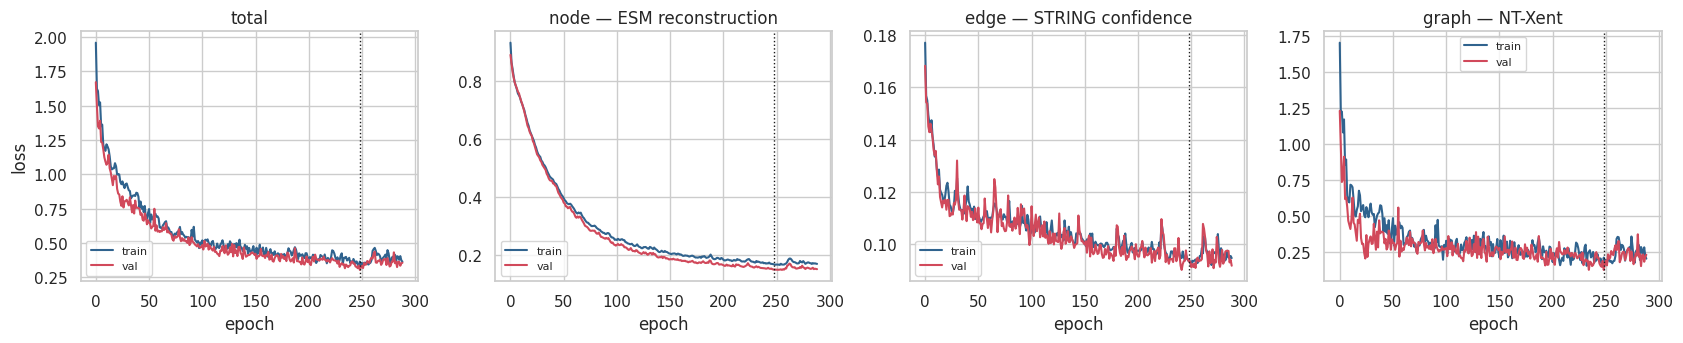

In [33]:
fig, ax = plt.subplots(1, 4, figsize=(17, 3.6))
for a, (col, title) in zip(ax, [("loss", "total"), ("node", "node — ESM reconstruction"),
                                ("edge", "edge — STRING confidence"), ("graph", "graph — NT-Xent")]):
    a.plot(history["epoch"], history[f"train_{col}"], label="train", color="#30638e")
    a.plot(history["epoch"], history[f"val_{col}"], label="val", color="#d1495b")
    a.axvline(best["epoch"], color="k", ls=":", lw=1)
    a.set(title=title, xlabel="epoch")
    a.legend(fontsize=8)
ax[0].set_ylabel("loss")
plt.tight_layout(); plt.show()

## 15 — Does the encoder actually learn anything?

Four questions, each with a baseline that a useless encoder would already match:

1. **Node** — is $h_i$ still the protein it started as? Cosine similarity between the reconstruction
   and the true identity vector, against the "predict the dataset mean protein" baseline.
2. **Edge** — held-out edges only: correlation with the true confidence, and how well real edges
   separate from sampled non-edges (AUC). A constant predictor gives AUC 0.5.
3. **Graph** — do two perturbed views of the same disease land next to each other? Top-1 retrieval
   among all graphs.
4. **Graph, harder** — does $h_G$ carry disease biology *beyond gene composition and graph size*?
   A linear probe for disease category on $h_G$, compared with probes on the mean ESM composition
   $\mu_G$ and on plain topology descriptors, plus the correlation of the $h_G$ similarity matrix with
   gene-overlap, composition and topology similarity. This is the ESM-vs-topology decomposition the
   plan asks for, run *before* any SAE so that the SAE's later claims have a reference point.

**Where the run stored in this notebook landed** — 90 graphs, 264-dim node features, structural block on:

| level | value | baseline |
|---|---|---|
| node — reconstruction cosine | 0.858 | 0.111 (predict the mean protein) |
| edge — held-out edges vs non-edges | **AUC 0.909** | 0.5 |
| edge — RMSE over scored pairs | 0.300 | 0.428 (constant predictor) |
| graph — two views retrieve the same disease | 98.9% | 1.1% (chance) |
| graph — disease-category probe on $h_G$ | 0.71 ± 0.04 | 0.81 (ESM composition), 0.23 (majority) |

The **edge level is where the encoder is unambiguously doing network inference**: those edges were
invisible to it, and it still tells them from sampled non-edges nine times out of ten. The graph
level still tracks *what is in the graph* more than *how it is wired* — $\rho = 0.737$ against ESM
composition versus $0.534$ against topology — which is what section 15's last table is for.

In [34]:
@torch.no_grad()
def collect(loader):
    # Node/edge/graph outputs of the frozen encoder, plus the raw composition baseline.
    model.eval()
    out = dict(cos=[], edge_pred=[], edge_true=[], edge_is_real=[], h_graph=[], mu_esm=[],
               y=[], names=[], target=[])
    for batch in loader:
        batch = batch.to(device)
        msg_index, msg_weight, pos_index, pos_score = mask_edges(batch)
        z_node, _ = model.encode(batch, edge_index=msg_index, edge_weight=msg_weight)

        target = batch.x[:, IDENTITY_START:]
        out["target"].append(target.cpu())
        out["cos"].append(F.cosine_similarity(model.node_decoder(z_node), target, dim=1).cpu())

        all_keys, _, _ = pair_keys(batch.edge_index, batch.num_nodes)
        neg_index = sample_negative_pairs(batch, pos_index.shape[1], all_keys.unique())
        pair_index = torch.cat([pos_index, neg_index], dim=1)
        out["edge_pred"].append(model.score_pairs(z_node, pair_index).cpu())
        out["edge_true"].append(torch.cat([pos_score,
                                           torch.zeros(neg_index.shape[1], device=device)]).cpu())
        out["edge_is_real"].append(torch.cat([torch.ones(pos_index.shape[1]),
                                              torch.zeros(neg_index.shape[1])]))

        _, h_graph = model.encode(batch)
        out["h_graph"].append(h_graph.cpu())
        out["mu_esm"].append(global_mean_pool(batch.x[:, IDENTITY_START:], batch.batch).cpu())
        out["y"].append(batch.y.cpu())
        out["names"].extend(batch.disease)

    res = {k: (torch.cat(v) if k != "names" else v) for k, v in out.items()}
    # Baseline: what cosine you get by predicting the dataset-mean protein for every node.
    mean_target = res["target"].mean(0, keepdim=True)
    res["baseline_cos"] = F.cosine_similarity(mean_target.expand_as(res["target"]),
                                              res["target"], dim=1)
    return res


val_res = collect(val_loader)
all_res = collect(all_loader)

print("── node level (validation graphs) ──")
print(f"cosine(reconstruction, true identity): mean {val_res['cos'].mean():.3f} "
      f"| median {val_res['cos'].median():.3f}")
print(f"baseline — predict the mean protein  : mean {val_res['baseline_cos'].mean():.3f}")

── node level (validation graphs) ──
cosine(reconstruction, true identity): mean 0.858 | median 0.877
baseline — predict the mean protein  : mean 0.111


── edge level (held-out edges of validation graphs) ──
pairs scored: 21,116 (10,996 real edges, 10,120 non-edges)
real vs non-edge separation   : AUC 0.909  (0.5 = uninformative)
confidence of real edges      : pearson r 0.190 | spearman 0.215
RMSE over all scored pairs    : 0.300 | constant-predictor RMSE 0.428


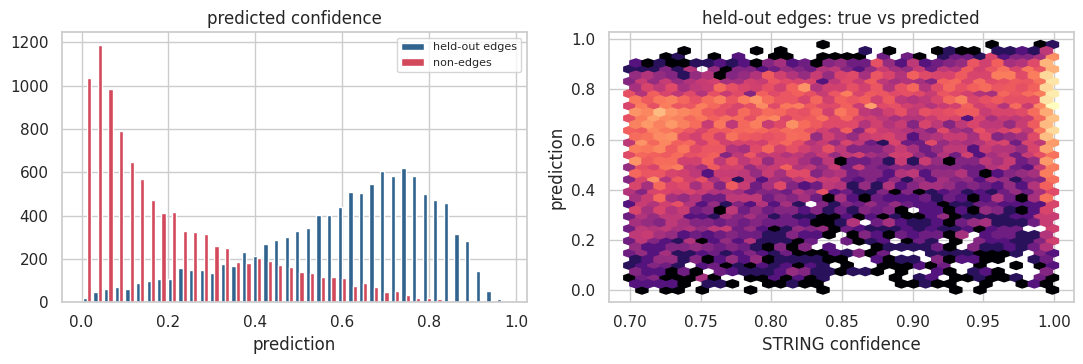

In [35]:
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import roc_auc_score

pred, true, real = val_res["edge_pred"].numpy(), val_res["edge_true"].numpy(), val_res["edge_is_real"].numpy()
pos = real == 1
print("── edge level (held-out edges of validation graphs) ──")
print(f"pairs scored: {len(pred):,} ({int(pos.sum()):,} real edges, {int((~pos).sum()):,} non-edges)")
print(f"real vs non-edge separation   : AUC {roc_auc_score(real, pred):.3f}  (0.5 = uninformative)")
print(f"confidence of real edges      : pearson r {pearsonr(pred[pos], true[pos])[0]:.3f} "
      f"| spearman {spearmanr(pred[pos], true[pos])[0]:.3f}")
print(f"RMSE over all scored pairs    : {np.sqrt(((pred - true) ** 2).mean()):.3f} "
      f"| constant-predictor RMSE {np.sqrt(((true.mean() - true) ** 2).mean()):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].hist([pred[pos], pred[~pos]], bins=40, label=["held-out edges", "non-edges"],
           color=["#30638e", "#d1495b"], stacked=False)
ax[0].set(title="predicted confidence", xlabel="prediction"); ax[0].legend(fontsize=8)
ax[1].hexbin(true[pos], pred[pos], gridsize=35, cmap="magma", bins="log")
ax[1].set(title="held-out edges: true vs predicted", xlabel="STRING confidence", ylabel="prediction")
plt.tight_layout(); plt.show()

In [36]:
# ── graph level: are two views of the same disease each other's nearest neighbour? ──
@torch.no_grad()
def view_retrieval(loader, repeats=5):
    model.eval()
    hits = total = 0
    for _ in range(repeats):
        v1, v2 = [], []
        for batch in loader:
            batch = batch.to(device)
            v1.append(encode_view(model, batch, augment(batch)).cpu())
            v2.append(encode_view(model, batch, augment(batch)).cpu())
        a = F.normalize(torch.cat(v1), dim=1)
        b = F.normalize(torch.cat(v2), dim=1)
        hits += int((a @ b.t()).argmax(dim=1).eq(torch.arange(a.shape[0])).sum())
        total += a.shape[0]
    return hits / total


acc = view_retrieval(all_loader)
print("── graph level ──")
print(f"two augmented views retrieve the same disease: {acc:.1%} top-1 "
      f"(chance {1 / len(graphs):.1%}, {len(graphs)} candidates)")

── graph level ──
two augmented views retrieve the same disease: 98.9% top-1 (chance 1.1%, 90 candidates)


In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Topology-only descriptors: what a model that ignored biology entirely could still know.
topo = np.array([[g.num_nodes, g.edge_index.shape[1] / 2,
                  (g.edge_index.shape[1] / 2) / max(g.num_nodes * (g.num_nodes - 1) / 2, 1),
                  float(g.edge_attr.mean()), float((g.edge_type == 0).float().mean())]
                 for g in graphs])

H = all_res["h_graph"].numpy()          # learned graph embedding
MU = all_res["mu_esm"].numpy()          # mean node identity — pure molecular composition
y = all_res["y"].numpy()

counts = pd.Series(y).value_counts()
n_splits = int(min(5, counts.min()))
if n_splits < 2:
    print("too few graphs per category for a cross-validated probe — skipping")
else:
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    probe = lambda X: cross_val_score(
        make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, C=1.0)),
        X, y, cv=cv, scoring="accuracy")
    rows = []
    for name, X in [("h_G (learned)", H), ("mean ESM composition", MU), ("topology only", topo),
                    ("h_G + topology", np.hstack([H, topo]))]:
        s = probe(X)
        rows.append(dict(features=name, dim=X.shape[1], accuracy=f"{s.mean():.2f} ± {s.std():.2f}"))
    rows.append(dict(features="majority class", dim=0,
                     accuracy=f"{counts.max() / counts.sum():.2f}"))
    print(f"── disease-category probe ({n_splits}-fold CV, {len(graphs)} graphs, "
          f"{counts.size} categories) ──")
    print(pd.DataFrame(rows).to_string(index=False))
    print("\nThe probe is a diagnostic, not an objective: the encoder never saw these labels.")

── disease-category probe (5-fold CV, 90 graphs, 6 categories) ──
            features  dim    accuracy
       h_G (learned)  128 0.71 ± 0.04
mean ESM composition  256 0.81 ± 0.08
       topology only    5 0.56 ± 0.10
      h_G + topology  133 0.71 ± 0.05
      majority class    0        0.23

The probe is a diagnostic, not an objective: the encoder never saw these labels.


In [38]:
# ── what does h_G track: gene composition, molecular composition, or network organisation? ──
def upper(m):
    return m[np.triu_indices_from(m, k=1)]


def cos_sim(X):
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True).clip(1e-9)
    return Xn @ Xn.T


sets = [set(g.string_ids) for g in graphs]
J = np.array([[len(a & b) / len(a | b) for b in sets] for a in sets])
topo_z = (topo - topo.mean(0)) / topo.std(0).clip(1e-9)
topo_sim = -np.linalg.norm(topo_z[:, None, :] - topo_z[None, :, :], axis=-1)   # negative distance

sim_h = cos_sim(H)
rows = []
for name, M in [("gene overlap (Jaccard)", J), ("ESM composition", cos_sim(MU)),
                ("topology similarity", topo_sim)]:
    r, p = spearmanr(upper(sim_h), upper(M))
    rows.append(dict(reference=name, spearman_rho=round(r, 3), p_value=f"{p:.1e}"))
print("── similarity of h_G vs independent references ──")
print(pd.DataFrame(rows).to_string(index=False))
print("\nA graph feature that is interesting later should not be fully explained by the first two "
      "rows;\nthis table is the reference point Part 3 will be read against.")

── similarity of h_G vs independent references ──
             reference  spearman_rho  p_value
gene overlap (Jaccard)         0.652  0.0e+00
       ESM composition         0.737  0.0e+00
   topology similarity         0.534 6.3e-294

A graph feature that is interesting later should not be fully explained by the first two rows;
this table is the reference point Part 3 will be read against.


plotting 90/90 graphs (excluded: )


/home/s243564/miniforge3/envs/gea/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


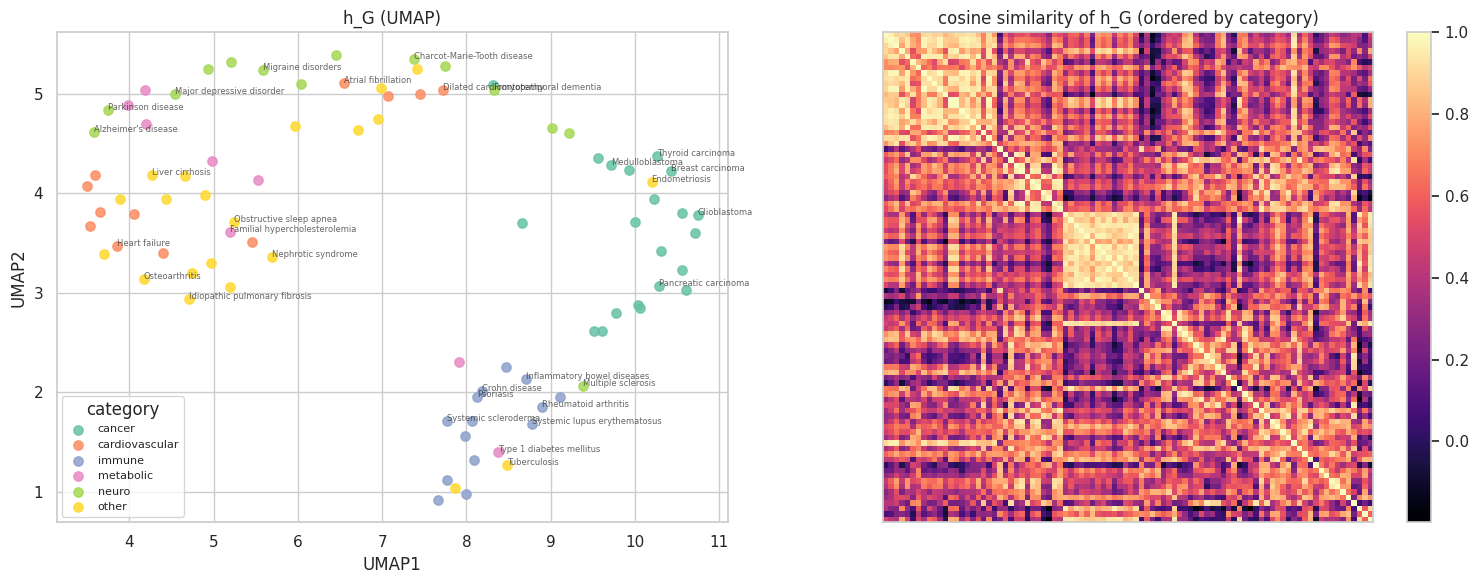

In [42]:
try:
    from umap import UMAP
except Exception:
    import umap.umap_ as umap
    UMAP = umap.UMAP

# Categories dropped from this figure only — every number computed above still uses all graphs.
EXCLUDE_CATEGORIES = {}

cats_all = np.array([g.category for g in graphs])
keep = np.where(~np.isin(cats_all, list(EXCLUDE_CATEGORIES)))[0]
cats = cats_all[keep]
names = [all_res["names"][i] for i in keep]
print(f"plotting {len(keep)}/{len(graphs)} graphs (excluded: {', '.join(sorted(EXCLUDE_CATEGORIES))})")

# Fitted on the retained graphs only, so the layout is theirs alone rather than a masked view of all.
coords = UMAP(n_components=2, random_state=SEED).fit_transform(
    StandardScaler().fit_transform(H[keep]))

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
for cat in sorted(set(cats)):
    m = cats == cat
    ax[0].scatter(coords[m, 0], coords[m, 1], s=45, label=cat, color=CATEGORY_PALETTE[cat], alpha=0.85)
ax[0].legend(fontsize=8, title="category"); ax[0].set(title="h_G (UMAP)", xlabel="UMAP1", ylabel="UMAP2")

label_every = max(1, len(keep) // 30)
for i, name in enumerate(names):
    if i % label_every == 0:
        ax[0].annotate(name, coords[i], fontsize=6, alpha=0.7)

order = keep[np.argsort([f"{graphs[i].category}|{graphs[i].disease}" for i in keep])]
im = ax[1].imshow(sim_h[np.ix_(order, order)], cmap="magma")
ax[1].set(title="cosine similarity of h_G (ordered by category)", xticks=[], yticks=[])
plt.colorbar(im, ax=ax[1], fraction=0.046)
plt.tight_layout(); plt.show()

### How to read section 15

* **Edge AUC is the cleanest signal, and it is the one that improved.** It is the one number that
  can only come from network structure: the encoder sees the graph with those edges removed. It now
  sits at **0.909** (RMSE 0.300 against 0.428 for a constant predictor), up from 0.867 on the same
  atlas without structural node features — the encoder is inferring wiring, not memorising it. The
  correlation *among real edges* stays low (r ≈ 0.19) as long as the atlas is built at
  `combined_score ≥ 700`, because the surviving confidences occupy a narrow band; that is a property
  of the dataset, not a failure of the model. Lower `STRING_MIN_SCORE` in Part 1 if you want that
  number to mean something.
* **If `mean ESM composition` matches or beats `h_G` in the probe** — as it still does here, 0.81
  against 0.71 — the encoder is not yet adding anything beyond "which proteins are in this graph",
  the exact confound the planning discussion worried about. Levers, roughly in order of effect: the
  readout (last bullet), more graphs, a larger `LAMBDA_GRAPH`, deeper message passing (`GCN_HIDDEN`).
  Note the probe is a 6-way problem on 90 graphs, so ±0.05 between runs means nothing; it is why this
  baseline is computed *before* any SAE rather than after.
* **The node cosine is modest by construction** when the identity block is whitened PCA — Part 1 uses
  `whiten=True`, which strips exactly the correlations that make reconstruction easy. What matters is
  the gap to the mean-protein baseline (0.858 against 0.111 here), not the absolute value; rebuild
  with `whiten=False` or raise `GCN_LATENT` if you want an easier target.
* **Retrieval near 100% with a weak probe** means the contrastive objective is solving its task by
  latching onto something stable but uninformative (graph size, for instance). Check it against the
  `topology only` probe row before concluding the graph level is working.
* **The readout is the real lever on what is left.** Structural node features were added for exactly
  this reason and measured: they buy a better edge level (AUC 0.867 → 0.899 in a controlled ablation,
  0.909 in this run), a stronger topology signal in $h_G$ (corr 0.456 → 0.534) and node states that
  are slightly less of a lookup table (identity dominance 0.944 → 0.929) — but they leave
  corr($h_G$, composition) at ~0.74. $h_G$ is a *mean* over node states, so
  it is a composition statistic by construction, and no augmentation fixes that — node dropping was
  measured and made it worse (see section 12). If the composition row keeps winning, change the
  readout rather than the noise: concatenate max- and attention-pooling to the mean, or pool over
  edge states $h_{ij}$ as well, so that how the proteins are wired can enter $h_G$ at all.

### Where this leaves Part 3

The encoder is frozen and checkpointed, and the numbers above are the reference the SAE results have
to beat. What comes next:

1. `gea.gea.extract_embeddings(model, all_loader, device, level=...)` for the node, edge and graph
   levels — the model's `encode` / `edge_predictor` signatures were chosen to fit it. Note that it
   also reads `model.classifier` for its `prediction` field, which a purely self-supervised encoder
   does not have; either attach the section-15 probe as a classifier head or export with a small
   custom writer.
2. Train the three SAEs unchanged (`gea.gea.ShallowSAE` / `train_sae`), so any difference against the
   LIONESS results is attributable to the dataset rather than the architecture.
3. Interpret: gene-set enrichment for node features, interaction programmes for edge features, and —
   the point of the whole exercise — ranked disease lists for graph features, checked against the
   composition/topology baselines computed here.